# Single-cell Neighborhood Analysis

Based on the original neighborhood analysis pipeline, the single-cell neighborhood analysis filtered the windows to include only one cell type (endothelial in this case).

In [ ]:
!pip install scanpy

In [1]:
import pandas as pd
import numpy as np
from sklearn.neighbors import NearestNeighbors
import time
import sys
import matplotlib.pyplot as plt
import math
import os
from itertools import product

from sklearn.cluster import MiniBatchKMeans
import seaborn as sns
import scanpy as sc

from scipy.spatial import KDTree
from scipy.spatial.distance import pdist, squareform
from matplotlib.colors import to_rgba

In [ ]:
pd.__version__
# import warnings
# warnings.filterwarnings("ignore")

##### Functions:

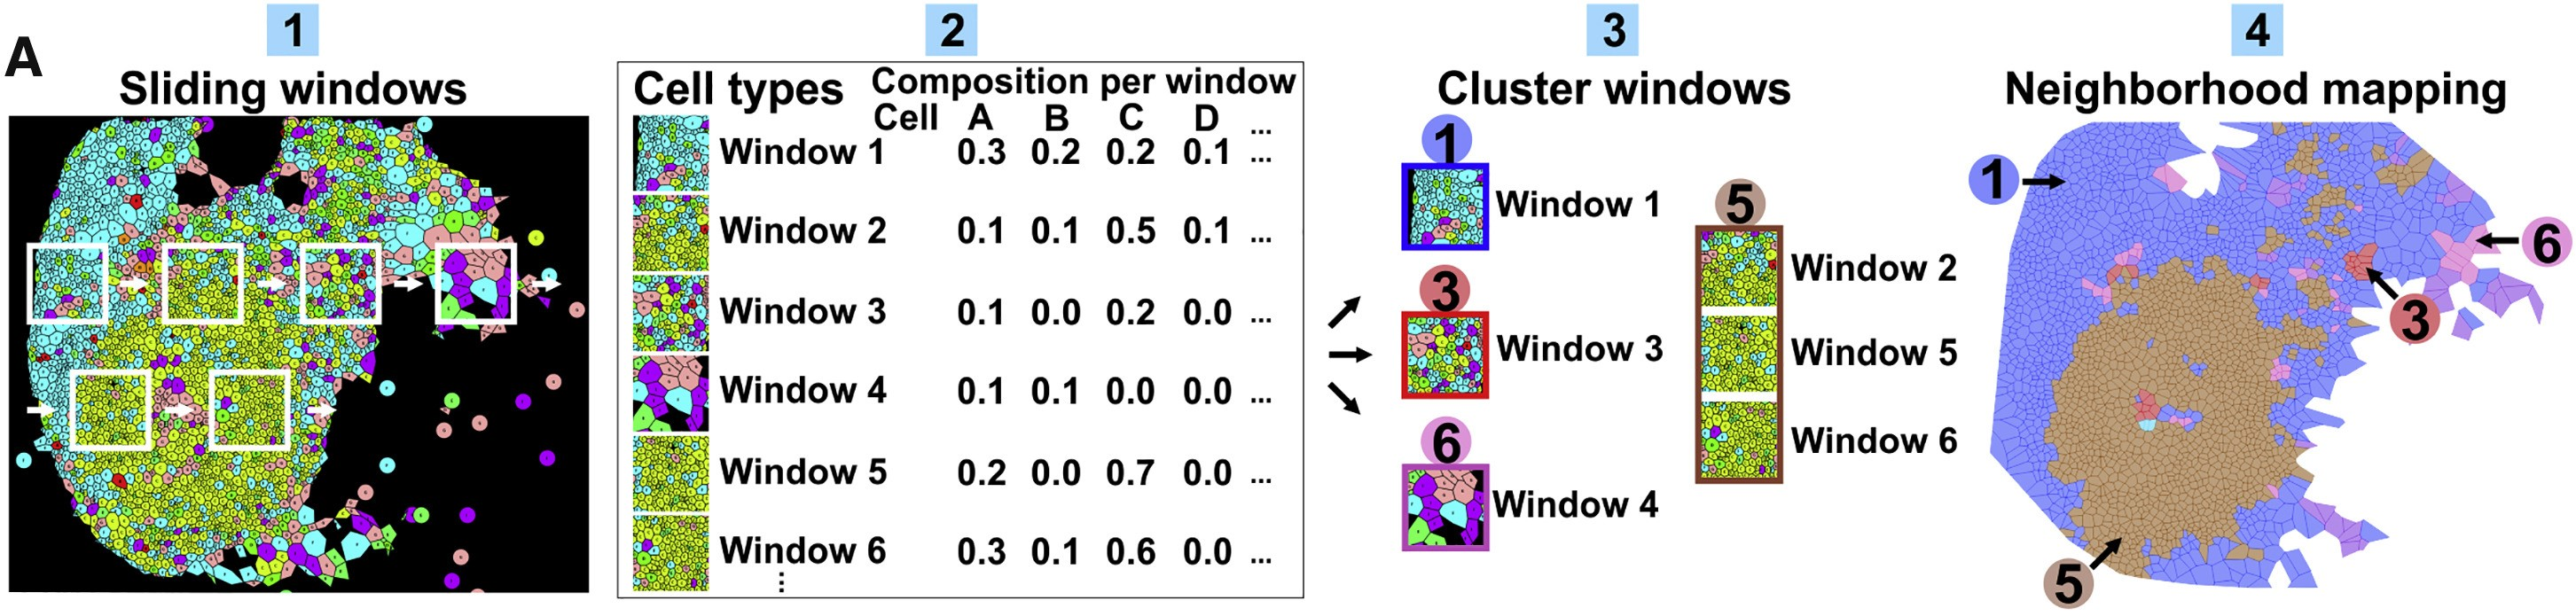

In [3]:
def get_windows(job,n_neighbors):
    start_time,idx,tissue_name,indices = job
    job_start = time.time()

    print ("Starting:", str(idx+1)+'/'+str(len(exps)),': ' + exps[idx])

    tissue = tissue_group.get_group(tissue_name)
    to_fit = tissue.loc[indices][[X,Y]].values

    fit = NearestNeighbors(n_neighbors=n_neighbors).fit(tissue[[X,Y]].values)
    m = fit.kneighbors(to_fit)

    #sort_neighbors
    args = m[0].argsort(axis = 1)
    add = np.arange(m[1].shape[0])*m[1].shape[1]
    sorted_indices = m[1].flatten()[args+add[:,None]]

    neighbors = tissue.index.values[sorted_indices]

    end_time = time.time()

    print ("Finishing:", str(idx+1)+"/"+str(len(exps)),": "+ exps[idx],end_time-job_start,end_time-start_time)
    return neighbors.astype(np.int32)

def get_adata(data, list_keep_obs=None, index_nam = 'tissue_index'):

    if list_keep_obs is None:
        list_keep_obs = ['first_index', 'x', 'y', 'tissue', 'donor', 'region', 'OLFM4', 'FAP',
       'CD25', 'CollIV', 'CK7', 'Xcorr', 'Ycorr', 'unique_region',
       'neigh_name', 'neigh_sub1', 'Preservation_method', 'Tissue_location',
       'array', 'Cell Type', 'Cell Type em', 'Cell subtype', 'machine',
       'MUC6', index_nam]
    data.reset_index(inplace=True)
    data.rename(columns={'index':index_nam}, inplace=True)

    #Prepare for making into anndata format so that obs and data are separate
    data_sc = data.drop(columns = list_keep_obs) #USER INPUT

    #Convert to anndata format
    adata = sc.AnnData(data_sc)
    adata.obs = data[list_keep_obs]
    m_list = adata.var.index.to_list()

    return adata, m_list


def adata_to_dataframe(adata):
    df_var = adata.to_df()
    df_obs = adata.obs
    df = pd.concat([df_var,df_obs], axis=1)
    return df


def sc_heat(data, cell_type, cell_col, vmax=5):
    data_subset = data[data.obs[cell_col] == cell_type]
    sc.pl.heatmap(data_subset, var_names=data.var_names, vmax=vmax, figsize=(20,10), show_gene_labels=True)


def swarm_box(data, grouping, replicate, sub_col, sub_list, per_cat, norm=True,\
              figure_sizing=(10,5), save_name=None, h_order=None):

    plt.style.use(['default'])
    #GENERAL GRAPH SETTINGs
    #font size of graph
    SMALL_SIZE = 14
    MEDIUM_SIZE = 16
    BIGGER_SIZE = 18

    #Settings for graph
    plt.rc('font', size=SMALL_SIZE)          # controls default text sizes
    plt.rc('axes', titlesize=SMALL_SIZE)     # fontsize of the axes title
    plt.rc('axes', labelsize=MEDIUM_SIZE)    # fontsize of the x and y labels
    plt.rc('xtick', labelsize=SMALL_SIZE)    # fontsize of the tick labels
    plt.rc('ytick', labelsize=SMALL_SIZE)    # fontsize of the tick labels
    plt.rc('legend', fontsize=SMALL_SIZE)    # legend fontsize
    plt.rc('figure', titlesize=BIGGER_SIZE)  # fontsize of the figure title

    #Find Percentage of cell type
    test= data.copy()
    sub_list1 = sub_list.copy()

    if norm==True:
        test1 = test.loc[test[sub_col].isin(sub_list1)]
        immune_list = list(test1[per_cat].unique())
    else:
        test1=test.copy()
        immune_list = list(test.loc[test[sub_col].isin(sub_list1)][per_cat].unique())

    test1[per_cat] = test1[per_cat].astype('category')
    test_freq = test1.groupby([grouping,replicate]).apply(lambda x: x[per_cat].value_counts(normalize = True,sort = False)*100)
    test_freq.columns = test_freq.columns.astype(str)
    test_freq.reset_index(inplace=True)
    immune_list.extend([grouping,replicate])
    test_freq1 = test_freq[immune_list]

    melt_per_plot = pd.melt(test_freq1, id_vars=[grouping,replicate,])#,value_vars=immune_list)
    melt_per_plot.rename(columns={'value': 'percentage'}, inplace=True)

    #Order by average
    plot_order = melt_per_plot.groupby(per_cat).mean().reset_index().sort_values(by='percentage')[per_cat].to_list()

    if h_order is None:
        h_order = list(melt_per_plot[grouping].unique())

    #swarmplot to compare clustering
    plt.figure(figsize=figure_sizing)
    ax = sns.boxplot(data = melt_per_plot, x=per_cat,  y='percentage', hue = grouping, dodge=True, order=plot_order,\
                     hue_order=h_order)
    ax = sns.swarmplot(data = melt_per_plot, x=per_cat, y='percentage', hue = grouping, dodge=True, order=plot_order,\
                      hue_order=h_order, edgecolor='black',linewidth=1)
    for patch in ax.artists:
        r, g, b, a = patch.get_facecolor()
        patch.set_facecolor((r, g, b, .3))
    #ax.set_yscale(\log\)
    plt.xlabel('')
    handles, labels = ax.get_legend_handles_labels()
    plt.legend(handles[:len(melt_per_plot[grouping].unique())], labels[:len(melt_per_plot[grouping].unique())],\
               bbox_to_anchor=(1.05, 1), loc=2, borderaxespad=0.,frameon=False)
    plt.xticks(rotation=90)
    sns.despine(trim=True)
    if save_name:
        plt.savefig(save_path+save_name+'_swarm_boxplot.png', format='png', dpi=300, transparent=True, bbox_inches='tight')

    return melt_per_plot

def stacked_bar_plot(data, per_cat, grouping, cell_list, norm=True, save_name=None,\
              col_order=None, sub_col=None, name_cat = 'Cell Type',fig_sizing=(8,4), pal_color=None):

    #Find Percentage of cell type
    cell_list_1 = cell_list.copy()
    test= data.copy()
    if norm==True:
        if sub_col is None:
            test1 = test.loc[test[per_cat].isin(cell_list_1)]
            sub_cell_list = list(test1[per_cat].unique())
        else:
            test1 = test.loc[test[sub_col].isin(cell_list_1)]
            sub_cell_list = list(test1[per_cat].unique())
    else:
        if sub_col is None:
            test1 = test.copy()
            sub_cell_list = list(test.loc[test[per_cat].isin(cell_list_1)][per_cat].unique())
        else:
            test1 = test.copy()
            sub_cell_list = list(test.loc[test[sub_col].isin(cell_list_1)][per_cat].unique())

    test1[per_cat] = test1[per_cat].astype('category')
    test_freq = test1.groupby(grouping).apply(lambda x: x[per_cat].value_counts(normalize = True,sort = False)*100)
    test_freq.columns = test_freq.columns.astype(str)

    ##### Can subset it here if I do not want normalized per the group
    test_freq.reset_index(inplace=True)
    sub_cell_list.append(grouping)
    test_freq = test_freq[sub_cell_list]
    melt_test = pd.melt(test_freq, id_vars=[grouping])#, value_vars=test_freq.columns)
    melt_test.rename(columns = {per_cat: name_cat, 'value':'percent'},  inplace = True)

    if norm==True:
        if col_order is None:
            bb = melt_test.groupby([grouping, per_cat]).sum().reset_index()
            col_order = bb.loc[bb[per_cat]==bb[per_cat][0]].sort_values(by='percent')[grouping].to_list()
    else:
        if col_order is None:
            col_order = melt_test.groupby(grouping).sum().reset_index().sort_values(by='percent')[grouping].to_list()

    #Set up for plotting
    melt_test_piv = pd.pivot_table(melt_test, columns = [name_cat], index=[grouping], values=['percent'])
    melt_test_piv.columns = melt_test_piv.columns.droplevel(0)
    melt_test_piv.reset_index(inplace=True)
    melt_test_piv.set_index(grouping, inplace=True)
    melt_test_piv = melt_test_piv.reindex(col_order)

    #Get color dictionary
    if pal_color is None:
        cond_list = list(melt_test_piv.columns)
        color_list=list(pal_temp.values())
        pal_color = dict(zip(cond_list, color_list))

    #first subplot
    ax1 = melt_test_piv.plot.bar(alpha = 0.8, linewidth=1, color=[pal_color.get(x) for x in melt_test_piv.columns]\
                                  , figsize =fig_sizing, rot=90,stacked=True, edgecolor='black')
    for line in ax1.lines:
        line.set_color('black')
    ax1.spines['top'].set_visible(False)
    ax1.spines['right'].set_visible(False)
    ax1.set_ylabel('percent')
    #ax1.spines['left'].set_position(('data', 1.0))
    #ax1.set_xticks(np.arange(1,melt_test.day.max()+1,1))
    #ax1.set_ylim([0, int(ceil(max(max(melt_test_piv.sum(axis=1)), max(tm_piv.sum(axis=1)))))])
    plt.xticks(list(range(len(list(melt_test_piv.index)))), list(melt_test_piv.index), rotation=90)
    lgd2 = ax1.legend(loc='center left', bbox_to_anchor=(1.0, 0.5), ncol=1, frameon=False)
    if save_name:
        plt.savefig(save_path+save_name+'.png', format='png',\
                    dpi=300, transparent=True, bbox_inches='tight')

def area_plot(data, per_cat, grouping, cell_list, sub_col, color_dict=None, \
              norm=False, save_name=None, col_order=None, name_cat = 'Cell Type',fig_sizing=(8,4)):
    if col_order is None:
        col_order=list(data[grouping].unique())

    cell_list_1 = cell_list.copy()
    #Find Percentage of cell type
    test= data.copy()
    if norm==True:
        test1 = test.loc[test[sub_col].isin(cell_list_1)]
        immune_list = list(test1[per_cat].unique())
    else:
        test1 = test.copy()
        immune_list = list(test.loc[test[sub_col].isin(cell_list_1)][per_cat].unique())

    test1[per_cat] = test1[per_cat].astype('category')
    test_freq = test1.groupby(grouping).apply(lambda x: x[per_cat].value_counts(normalize = True,sort = False)*100)
    test_freq.columns = test_freq.columns.astype(str)

    ##### Can subset it here if I do not want normalized per the group
    test_freq.reset_index(inplace=True)
    immune_list.append(grouping)
    test_freq = test_freq[immune_list]
    melt_test = pd.melt(test_freq, id_vars=[grouping])#, value_vars=test_freq.columns)
    melt_test.rename(columns = {per_cat: name_cat, 'value':'percent'},  inplace = True)

    #Set up for plotting
    melt_test_piv = pd.pivot_table(melt_test, columns = [name_cat], index=[grouping], values=['percent'])
    melt_test_piv.columns = melt_test_piv.columns.droplevel(0)
    melt_test_piv.reset_index(inplace=True)
    melt_test_piv.set_index(grouping, inplace=True)
    melt_test_piv = melt_test_piv.reindex(col_order)
    col_order2 = melt_test_piv.mean().sort_values(ascending=False).index.to_list()
    melt_test_piv= melt_test_piv[col_order2]

    #Get color dictionary
    if color_dict is None:
        cond_list = melt_test_piv.columns.to_list()
        color_list=list(pal_temp.values())
        color_dict = dict(zip(cond_list, color_list))

    #first subplot
    ax1 = melt_test_piv.plot.area(alpha = 0.8, linewidth=1, color=[color_dict.get(x) for x in melt_test_piv.columns], figsize =fig_sizing, rot=90)
    for line in ax1.lines:
        line.set_color('black')
    ax1.spines['top'].set_visible(False)
    ax1.spines['right'].set_visible(False)
    ax1.set_ylabel('percent')
    #ax1.spines['left'].set_position(('data', 1.0))
    #ax1.set_xticks(np.arange(1,melt_test.day.max()+1,1))
    #ax1.set_ylim([0, int(ceil(max(max(melt_test_piv.sum(axis=1)), max(tm_piv.sum(axis=1)))))])

    lgd2 = ax1.legend(loc='center left', bbox_to_anchor=(1.0, 0.5), ncol=1, frameon=False)
    if save_name:
        plt.savefig(save_path+save_name+'_areaplot.png', format='png', dpi=300, transparent=True, bbox_inches='tight')
    #return melt_test_piv

def percent_plot(cells, per, grouping, x_ax, color_col, save_name, transp = True):

    #dataframe of percentages of interest
    cells[per] = cells[per].astype('category')
    neigh_freqs = cells.groupby(grouping).apply(lambda x: x[per].value_counts(normalize = True,sort = False)*100)

    #transpose or not
    if transp==True:
        per_plot = neigh_freqs.T
    else:
        per_plot = neigh_freqs

    #Order by average
    per_plot_ave = (per_plot.mean(axis=1)).to_frame().reset_index()
    per_plot_ave = per_plot_ave.rename(columns = {0:'percent'})
    per_plot_ave = per_plot_ave.sort_values(by = 'percent')
    per_plot_order = per_plot_ave.set_index(x_ax)
    per_plot_order_t = per_plot_order.T
    col_order_list_1 = per_plot_order_t.columns.to_list()

    #melt the data so that can plot on swarmplot
    per_plot.columns = per_plot.columns.astype(str)
    melt_per_plot = pd.melt(per_plot.reset_index(), id_vars=x_ax, value_vars=per_plot.columns[:])
    melt_per_plot.rename(columns={'value': 'percent'}, inplace=True)

    #swarmplot to compare clustering
    plt.figure(figsize=(20, 5))
    ax1 = sns.swarmplot(data = melt_per_plot, x=x_ax, y = 'percent', hue=color_col, order = col_order_list_1, size=8)
    ax1 = sns.pointplot(x_ax, 'percent',data=melt_per_plot, join=False, ci='sd', color='black', errwidth=1, capsize=.2, order = col_order_list_1)
    plt.xlabel('')
    plt.legend(bbox_to_anchor=(1.05, 1), loc=2, borderaxespad=0.)
    plt.xticks(rotation=90)
    plt.savefig(save_path+save_name+'_percent.png', format='png', dpi=300, transparent=True, bbox_inches='tight')
    return melt_per_plot

# Updated catplot function
#Imaging function that provides a high resolution overview of spatial data that is scaled appropriately
def catplot21(df, hue, exp='Exp', X='X', Y='Y', invert_y=False, size=3, legend=True, palette='bright', figsize=5, style='white', exps=None, axis='on', scatter_kws={}, **kwargs):
    '''
    Plots cells in tissue section color coded by either cell type or node allocation.
    df:  dataframe with cell information
    size:  size of point to plot for each cell.
    hue:  color by "Clusterid" or "Node" respectively.
    legend:  to include legend in the plot.
    '''

    # Set default parameters for scatter plots
    scatter_kws_ = {'s': size, 'alpha': 1}
    scatter_kws_.update(scatter_kws)
    print(scatter_kws_)

    figures = []  # List to store plot figures
    axes = []  # List to store plot axes
    df = df.rename(columns=lambda x: str(x))  # Ensure column names are strings

    df[hue] = df[hue].astype('category')  # Convert the hue column to a category

    if invert_y:
        y_orig = df[Y].values.copy()
        df[Y] *= -1

    # Set Seaborn style
    style = {'axes.facecolor': style}
    sns.set_style(style)

    if exps is None:
        exps = list(df[exp].unique())  # Display all experiments if not specified
    elif not isinstance(exps, list):
        exps = [exps]

    for name in exps:
        data = df[df[exp] == name]

        data[X] = data[X] - data[X].min()  # Normalize X coordinates
        data[Y] = data[Y] - data[Y].min()  # Normalize Y coordinates

        xrange = data[X].max() - data[X].min()
        yrange = data[Y].max() - data[Y].min()


        # Create a scatter plot using Seaborn's lmplot
        f = sns.lmplot(x=X, y=Y, data=data, hue=hue,
                       legend=legend, fit_reg=False, markers='.', height=yrange / 400, palette=palette, scatter=True, scatter_kws=scatter_kws_, aspect=xrange / yrange, **kwargs)
        
        ax = f.ax  # Get the plot axes
        
        if axis == 'off':
            sns.despine(top=True, right=True, left=True, bottom=True)
            f = f.set(xticks=[], yticks=[]).set_xlabels('').set_ylabels('')

        plt.title(name)  # Set the plot title
        plt.show()
        figures += [f]
        axes += [ax]

    if invert_y:
        df[Y] = y_orig  # Restore the original Y values

    return figures, axes

##### Processing code:

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

In [ ]:
! git clone https://github.com/HickeyLab/Hierarchical-Tissue-Unit-Annotation.git

In [4]:
#Choose this information and input based on above
ks = [5,10,30,50,100,300] # k=5 means it collects 5 nearest neighbors for each center cell
path_to_data = '/Users/jodie/Documents/23_09_CODEX_HuBMAP_alldata_Dryad_merged.csv'

X = 'x'
Y = 'y'
reg = 'unique_region'
file_type = 'csv'

cellhier_path = '/Users/jodie/OneDrive/Documents/Python Scripts/Hierarchical-Tissue-Unit-Annotation'
sys.path.append(cellhier_path)
from cellhier.general import *
from cellhier.plot_john import *
from cellhier.knn_graph_neighborhood2 import *  # Imports everything

cluster_col = 'Cell Type'
keep_cols = [X,Y,reg,cluster_col]
save_path = '/Users/jodie/OneDrive/Documents/Duke/Hickey Lab/panorgan'

In [5]:
#Import Data

n_neighbors = max(ks)

cells = pd.read_csv(path_to_data)
cells = pd.concat([cells,pd.get_dummies(cells[cluster_col], dtype=int)],axis=1)
sum_cols = cells[cluster_col].unique()
values = cells[sum_cols].values

In [6]:
#Get each region
tissue_group = cells[[X,Y,reg]].groupby(reg)
exps = list(cells[reg].unique())
tissue_chunks = [(time.time(),exps.index(t),t,a) for t,indices in tissue_group.groups.items() for a in np.array_split(indices,1)]
tissues = [get_windows(job,n_neighbors) for job in tissue_chunks]

Starting: 1/66 : B004_Ascending
Finishing: 1/66 : B004_Ascending 0.7553272247314453 0.7579994201660156
Starting: 9/66 : B004_Descending
Finishing: 9/66 : B004_Descending 1.0361080169677734 1.8050942420959473
Starting: 51/66 : B004_Descending - Sigmoid
Finishing: 51/66 : B004_Descending - Sigmoid 0.8974969387054443 2.720646381378174
Starting: 18/66 : B004_Duodenum
Finishing: 18/66 : B004_Duodenum 1.497962236404419 4.235208511352539
Starting: 25/66 : B004_Ileum
Finishing: 25/66 : B004_Ileum 0.8906097412109375 5.1566619873046875
Starting: 34/66 : B004_Mid-jejunum
Finishing: 34/66 : B004_Mid-jejunum 1.2377543449401855 6.411961793899536
Starting: 42/66 : B004_Proximal Jejunum
Finishing: 42/66 : B004_Proximal Jejunum 1.0140395164489746 7.454089164733887
Starting: 59/66 : B004_Transverse
Finishing: 59/66 : B004_Transverse 1.1293015480041504 8.61381220817566
Starting: 2/66 : B005_Ascending
Finishing: 2/66 : B005_Ascending 0.6076469421386719 9.248403310775757
Starting: 10/66 : B005_Descending
F

In [7]:
#Loop over k to compute neighborhoods
out_dict = {}
for k in ks:
    for neighbors,job in zip(tissues,tissue_chunks):

        chunk = np.arange(len(neighbors))#indices
        tissue_name = job[2]
        indices = job[3]
        window = values[neighbors[chunk,:k].flatten()].reshape(len(chunk),k,len(sum_cols)).sum(axis = 1)
        out_dict[(tissue_name,k)] = (window.astype(np.float16),indices)

windows = {}
for k in ks:

    window = pd.concat([pd.DataFrame(out_dict[(exp,k)][0],index = out_dict[(exp,k)][1].astype(int),columns = sum_cols) for exp in exps],axis=0)
    window = window.loc[cells.index.values]
    window = pd.concat([cells[keep_cols],window],axis=1)
    windows[k] = window

#### Endothelial Cell Type-Focused Neighborhood Analysis

Looking at different nearest number of cells $k$ around endothelial cells and use K means clustering to them as 1 neighborhood. By comparing the composition of each neighborhood with different $k$ values we can see the different tissue structures impacted by distances around endothelial cells.

Cell-type centric neighborhood analysis of endothelial cells. Identify cellls that are co-enriched as neighbors of endothelial cells.

In [8]:
cells[cluster_col].unique()

array(['NK', 'Enterocyte', 'MUC1+ Enterocyte', 'TA', 'CD66+ Enterocyte',
       'Paneth', 'Smooth muscle', 'M1 Macrophage', 'Goblet',
       'Neuroendocrine', 'CD57+ Enterocyte', 'Lymphatic', 'CD8+ T', 'DC',
       'M2 Macrophage', 'B', 'Neutrophil', 'Endothelial', 'Cycling TA',
       'Plasma', 'CD4+ T cell', 'Stroma', 'Nerve', 'ICC', 'CD7+ Immune'],
      dtype=object)

In [9]:
non_endo_color = (0.8627450980392157+(1-0.8627450980392157)/2.5, 0.8627450980392157+(1-0.8627450980392157)/2.5, 0.8627450980392157+(1-0.8627450980392157)/2.5)

In [10]:
os.environ['OMP_NUM_THREADS'] = '4' # For running on Windows with MKL

#Fill in based on above
k = 50 # neighborhood size
n_neighborhoods = 20 # number of neighbors
neighborhood_name = "neighborhood"+str(k)
k_centroids = {}

#choose windows with k calculated of interest
cluster_col1 = 'Neighborhood' # 'Neighborhood' for community analysis, 'Cell Type' for neighborhood analysis
windows2 = windows[k]
windows2[cluster_col1] = cells[cluster_col1]

#Only use T cell windows for example in cell_list
cell_name = 'endothelial cells'
#cell_list = ['Paneth','OLFM4+ Enterocyte']
cell_list = ['Endothelial']
cluster_col = 'Cell Type'
celltype_windows = windows2[windows2[cluster_col].isin(cell_list)]
type_cells = cells[cells[cluster_col].isin(cell_list)]

#Add labels
km = MiniBatchKMeans(n_clusters = n_neighborhoods,random_state=0)

labels = km.fit_predict(celltype_windows[sum_cols].values)
k_centroids[k] = km.cluster_centers_
type_cells[neighborhood_name] = labels

#Get out heat
k_to_plot = k
niche_clusters = (k_centroids[k_to_plot])
tissue_avgs = values.mean(axis = 0)
fc = np.log2(((niche_clusters+tissue_avgs)/(niche_clusters+tissue_avgs).sum(axis = 1, keepdims = True))/tissue_avgs)
fc = pd.DataFrame(fc,columns = sum_cols)
fc_output = fc.rename(index={0:k})
niche_aveg = pd.DataFrame(niche_clusters,columns = sum_cols)
niche_avegg = niche_aveg/niche_aveg.sum(axis=1)[0]*100

# type_cells.to_csv('type_cells.csv', index=False)

In [11]:
# Calculate the average nearest-neighbor distance for endothelial cells
nbrs = NearestNeighbors(n_neighbors=2).fit(type_cells[['x', 'y']])
distances, _ = nbrs.kneighbors(type_cells[['x', 'y']])

# Skip the 0 distance to self and take the nearest neighbor
nearest_neighbor_dists = distances[:, 1]
avg_nn_distance = nearest_neighbor_dists.mean()
print("Average endothelial cell nearest-neighbor distance:", avg_nn_distance)

Average endothelial cell nearest-neighbor distance: 10.739215333812048


In [12]:
# For plotting endothelial cells and neighbors
cells_subset = cells[['x', 'y', 'Xcorr', 'Ycorr', 'donor', 'unique_region', 'Cell Type']]
cells_coords = cells_subset.loc[cells_subset['unique_region']=='B010_Ileum']
type_cells_coords = cells_coords[['x', 'y']]
tree = KDTree(type_cells_coords)

In [13]:
# For plotting endothelial cells and neighbors
original_indices = cells_coords.index
cells_endo = cells_coords.loc[cells_coords['Cell Type']=='Endothelial']
cells_endo_coords = cells_endo[['x', 'y']]
num_endo = len(cells_endo_coords)
all_neighbors = []
num_neighbors = k
print('Number of nearest neighbrs:', num_neighbors)
for i in range(num_endo):
    ref_point = cells_endo_coords.iloc[i]
    distances, indices = tree.query(ref_point, k=num_neighbors)
    nearest_neighbors_indices = original_indices[indices[1:]]
    nearest_neighbors = type_cells_coords.loc[nearest_neighbors_indices]
    all_neighbors.append(nearest_neighbors)

all_neighbors_df = pd.concat(all_neighbors)
all_neighbors_df['y'] = -all_neighbors_df['y']

Number of nearest neighbrs: 50


In [14]:
cells_copy_celltype = cells.copy()

{'s': 10, 'alpha': 1}


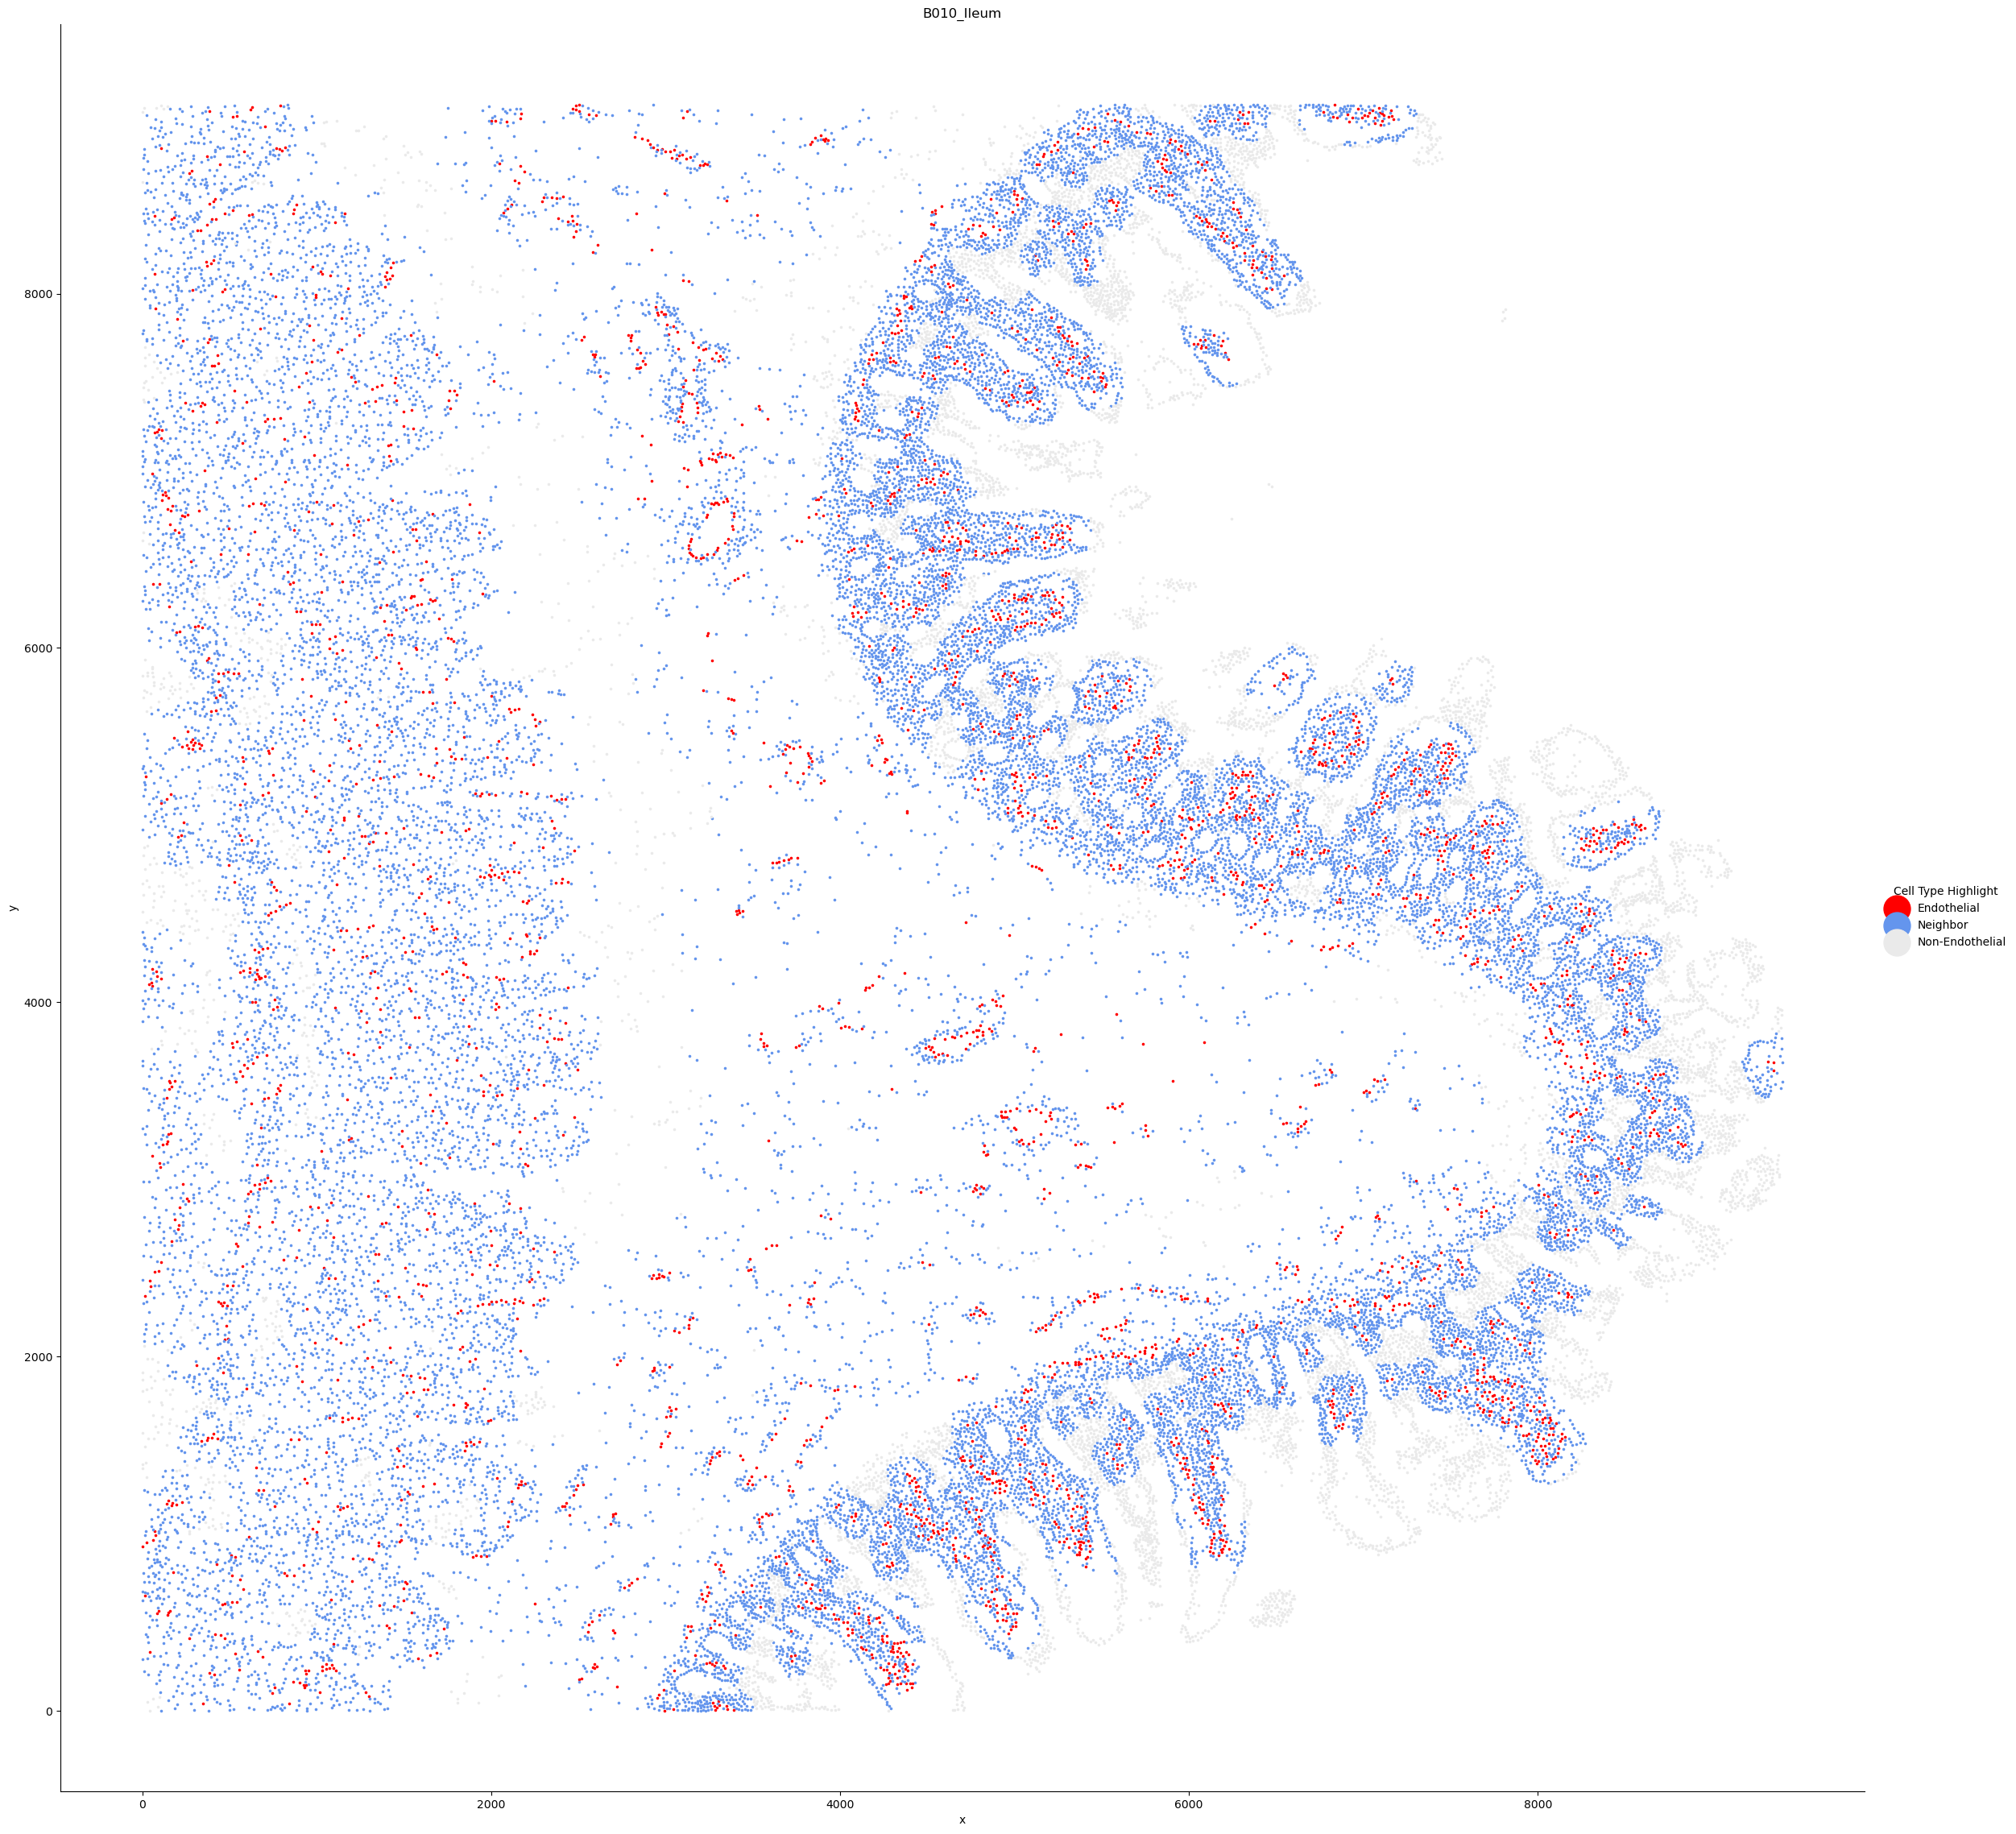

In [15]:
# Catplot highlighting endothelial cells
# Create the 'Cell Type Highlight' column, defaulting to the original 'Cell Type' logic
cells_copy_celltype['Cell Type Highlight'] = cells_copy_celltype['Cell Type'].apply(lambda x: 'Endothelial' if x == 'Endothelial' else 'Non-Endothelial')
cell_highlight_size = 200
size = 20
cells_copy_celltype['point_size'] = cells_copy_celltype['Cell Type Highlight'].apply(lambda x: cell_highlight_size if x == 'Endothelial' else size)
# Update the neighbors, but only for cells that are not endothelial
cells_copy_celltype.loc[all_neighbors_df.index, 'Cell Type Highlight'] = cells_copy_celltype.loc[all_neighbors_df.index, 'Cell Type Highlight'].apply(
    lambda x: 'Neighbor' if x != 'Endothelial' else x
)

# Define colors for the cell types
custom_palette = {
    'Endothelial': 'red',  # Color for endothelial cells
    'Non-Endothelial': non_endo_color,         # Color for all other cells
    'Neighbor': 'cornflowerblue',  # Color for nearest neighbors
}

# Use the updated DataFrame with the `Cell Type Highlight` column
plt.rcParams["legend.markerscale"] = 15
sub_cells = cells_copy_celltype.loc[cells_copy_celltype['unique_region']=='B010_Ileum']

figs, axes = catplot21(sub_cells, X='x', Y='y', exp=reg, hue='Cell Type Highlight',  # Updated column to highlight endothelial cells
    invert_y=True, size=10, figsize=8, exps=None, axis='on',scatter_kws={},palette=custom_palette,  # Use the custom color palette
)

Index(['M1 Macrophage', 'NK', 'DC', 'CD4+ T cell', 'Endothelial', 'Neutrophil',
       'Lymphatic', 'M2 Macrophage', 'ICC', 'Stroma', 'Smooth muscle', 'Nerve',
       'B', 'MUC1+ Enterocyte', 'CD57+ Enterocyte', 'Paneth', 'Neuroendocrine',
       'Cycling TA', 'TA', 'Goblet', 'Enterocyte', 'CD66+ Enterocyte',
       'Plasma', 'CD8+ T', 'CD7+ Immune'],
      dtype='object')


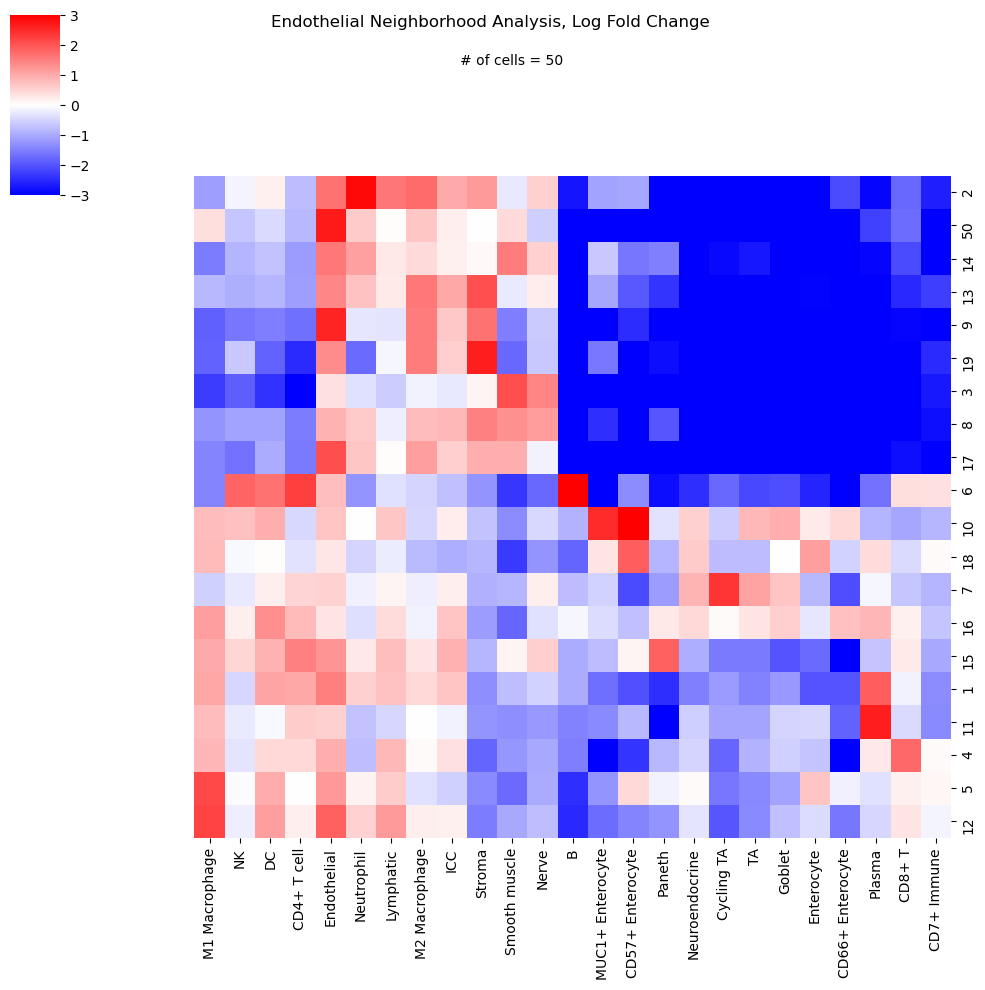

In [16]:
#this plot shows the types of cells (ClusterIDs) in the different neighborhoods
# k_to_plot = k
# niche_clusters = (k_centroids[k_to_plot])
# tissue_avgs = values.mean(axis = 0)
# fc = np.log2(((niche_clusters+tissue_avgs)/(niche_clusters+tissue_avgs).sum(axis = 1, keepdims = True))/tissue_avgs)
# fc = pd.DataFrame(fc,columns = sum_cols)
# fixed_order = fc_output[''].to_list()

s=sns.clustermap(fc_output, vmin =-3,vmax = 3,cmap = 'bwr', figsize=(10,10)) #col_cluster = fixed_order
s.ax_row_dendrogram.set_visible(False)  # Hide the row dendrogram
s.ax_col_dendrogram.set_visible(False) 
y_axis_order = s.dendrogram_row.reordered_ind
x_axis_order = s.dendrogram_col.reordered_ind
x_axis_labels = fc_output.columns[x_axis_order]
s.fig.suptitle('Endothelial Neighborhood Analysis, Log Fold Change')
titlename = '# of cells = '+str(k)
s.fig.text(x=0.47, y=0.93, s = titlename )
print(x_axis_labels)

In [ ]:
# To plot a subset of the clustermap
fc_output1 = fc_output.copy().iloc[[2,3,7],:]
s = sns.clustermap(fc_output1, vmin=-3, vmax=3, cmap='bwr', figsize=(10, 5))

In [ ]:
# To plot specific neighborhoods
nbhds_to_plot = [1, 2]
plt.rcParams["legend.markerscale"] = 15
sub_cells = type_cells.loc[(type_cells['donor']=='B010') & (type_cells[neighborhood_name].isin(nbhds_to_plot))]
figs, axes = catplot21(sub_cells, X = 'x', Y='y', exp = reg,
               hue = neighborhood_name, invert_y=True, figsize=8, exps=None, axis='on')



In [17]:
# Combine Clusters
# Cluster annotations based on k=50 and n=20

neighborhood_name_merged = neighborhood_name + '_merged'
merged_nbhds = {0:'Endothelial Rich',
                1:'Plasma Cell Enriched',
                2:'Stroma + Innate Immune',
                3:'Innervated Smooth Muscle',
                4:'Immune Enriched',
                5:'Immune Enriched',
                6:'Follicle',
                7:'Cycling TA',
                8:'Smooth Muscle + Innate Immune',
                9:'Stroma',
                10:'Glandular Epithelial',
                11:'Plasma Cell Enriched',
                12:'Immune Enriched',
                13:'Stroma',
                14:'Smooth Muscle + Innate Immune',
                15:'Paneth + Immune',
                16:'Cycling TA',
                17:'Smooth Muscle + Innate Immune',
                18:'Glandular Epithelial',
                19:'Stroma'
                }
type_cells_merged = type_cells.copy()
type_cells_merged[neighborhood_name_merged] = type_cells_merged[neighborhood_name].replace(merged_nbhds)
# type_cells_merged.to_csv('type_cells_merged.csv', index=False)

muscularisexterna_keys = ['Innervated Smooth Muscle', 'Smooth Muscle + Innate Immune']
submucosa_keys = ['Stroma + Innate Immune', 'Stroma', 'Endothelial Rich']
mucosa_keys = ['Immune Enriched', 'Follicle', 'Glandular Epithelial', 'Paneth + Immune', 'Cycling TA', 'Plasma Cell Enriched']

{'s': 10, 'alpha': 1}


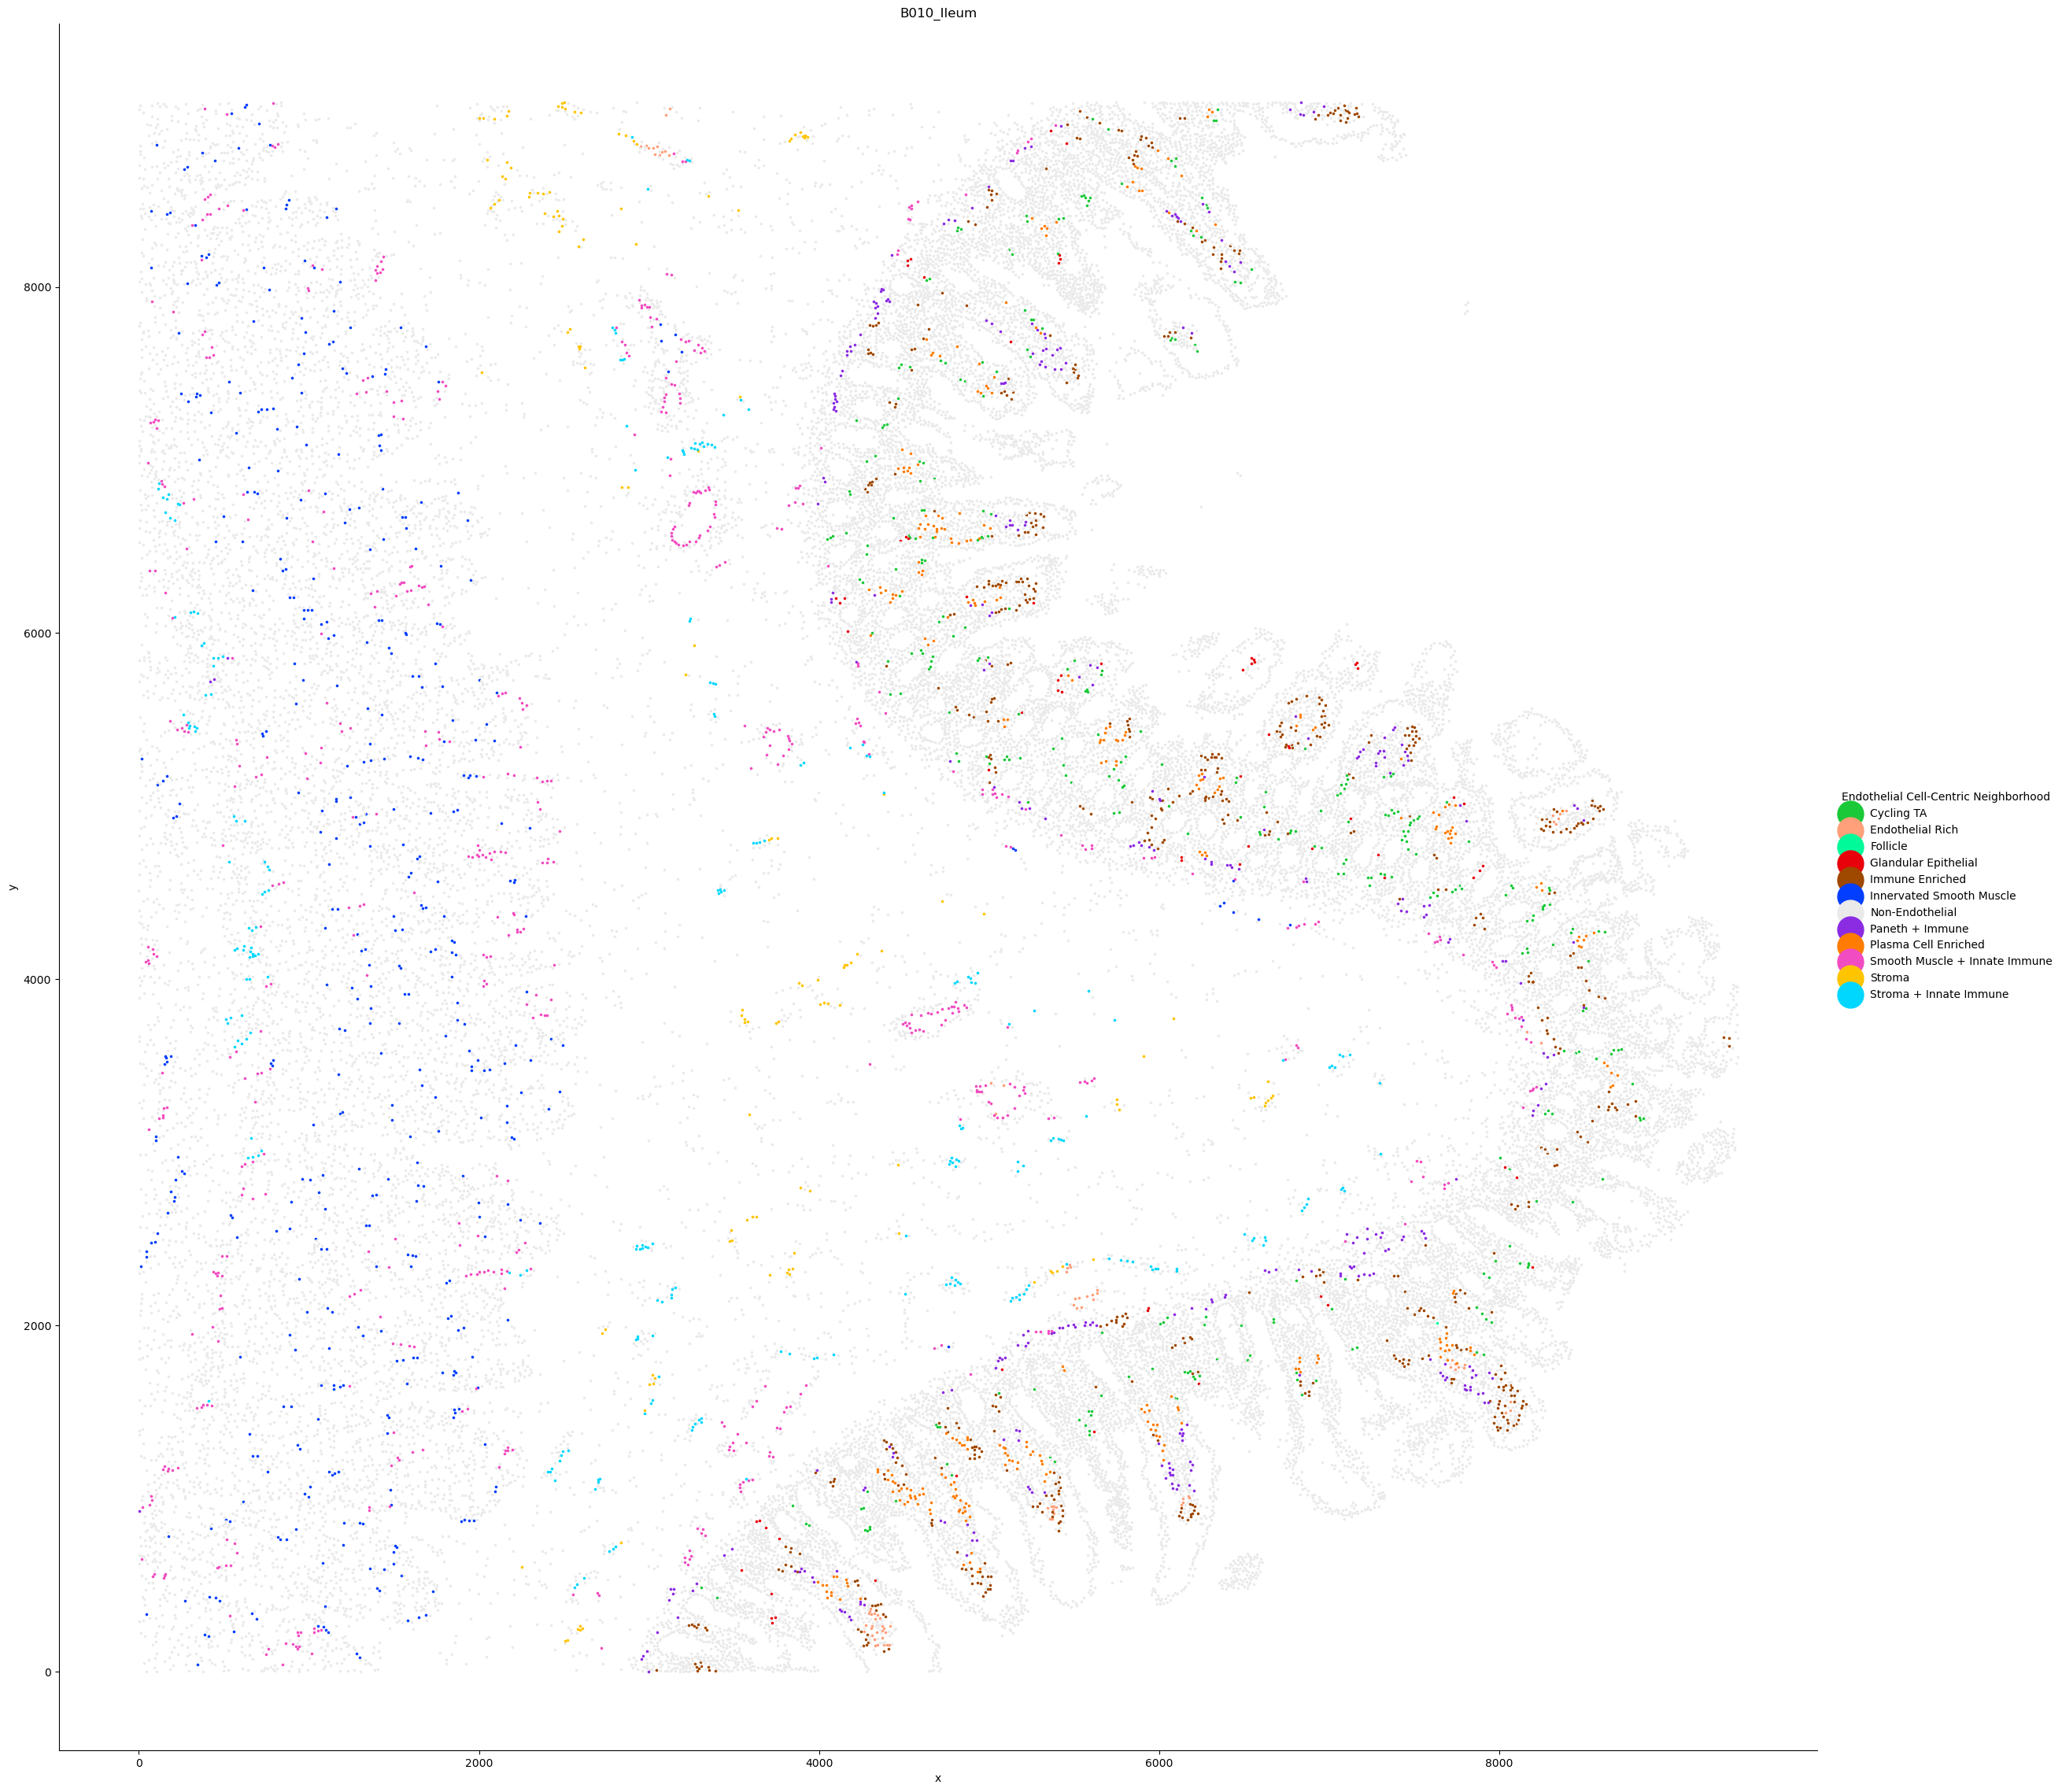

In [18]:
# Catplot of endothelial cell-centric neighborhoods
cells['Endothelial Cell-Centric Neighborhood'] = 'Non-Endothelial'  # Default category for cells not in type_cells

# Update the column for rows in type_cells
cells.loc[type_cells_merged.index, 'Endothelial Cell-Centric Neighborhood'] = type_cells_merged[neighborhood_name_merged]
unique_categories = cells['Endothelial Cell-Centric Neighborhood'].unique()
category_palette = sns.color_palette('bright', len(unique_categories))

# Create a custom palette with 'Other' explicitly set to gray
custom_palette = {**{cat: col for cat, col in zip(unique_categories, category_palette)}, 'Non-Endothelial': non_endo_color}
custom_palette['Follicle'] = 'mediumspringgreen'
custom_palette['Endothelial Rich'] = 'lightsalmon'

plt.rcParams["legend.markerscale"] = 15
sub_cells = cells.loc[cells['unique_region']=='B010_Ileum']
figs = catplot21( sub_cells, X='x', Y='y', exp=reg, hue= 'Endothelial Cell-Centric Neighborhood', # Updated column to highlight endothelial cells
    invert_y=True, size=10, figsize=8, exps=None, axis='on', scatter_kws={}, palette= custom_palette  # Use the custom color palette
)

In [19]:
# For attaching neighborhood colors to clustermap
cell_list = list(cells['Cell Type'].unique())
neigh_list = list(cells['Neighborhood'].unique())
endo_list = list(cells['Endothelial Cell-Centric Neighborhood'].unique())
color_list=list(custom_palette.values())
dict_cell = dict(zip(cell_list, color_list))
dict_neigh = dict(zip(neigh_list, color_list))
dict_endo = dict(zip(endo_list, color_list))

In [20]:
endo_data = pd.DataFrame({
    'Endothelial Cell-Centric Neighborhood':list(dict_endo.keys()),
    'color':list(dict_endo.values())
})
endo_data.set_index(keys='Endothelial Cell-Centric Neighborhood',inplace=True)

rgba_gainsboro = to_rgba('gainsboro')
rgba_lightsalmon = to_rgba('lightsalmon')
rgba_mediumspringgreen = to_rgba('mediumspringgreen')
endo_data.loc['Non-Endothelial', 'color'] = non_endo_color
endo_data.loc['Endothelial Rich', 'color'] = rgba_lightsalmon
endo_data.loc['Follicle', 'color'] = rgba_mediumspringgreen


In [21]:
# wrapped function to calculate fold change and neighborhood averages
# helpful for merging neighborhoods and rings analysis later on
def fc_out1(data, k_num, nbhd, type_nbhd_column):
    #Fill in based on above
    k = k_num
    n_neighborhoods = 1
    neighborhood_name = "neighborhood"+str(k)
    k_centroids = {}

    #choose windows with k calculated of interest
    windows2 = windows[k]
    windows2[cluster_col] = data[cluster_col]
    windows2[type_nbhd_column] = data[type_nbhd_column]

    #Only use T cell windows for example in cell_list
    cell_name = 'endothelial cells'
    #cell_list = ['Paneth','OLFM4+ Enterocyte']
    cell_list = ['Endothelial']
    nbhd_list = [nbhd]
    celltype_windows = windows2[windows2[cluster_col].isin(cell_list)]
    type_data = data[data[cluster_col].isin(cell_list)]

    celltype_windows_nbhd = windows2[windows2[type_nbhd_column].isin(nbhd_list)] # for neighborhood rings analysis, otherwise use celltype_windows
    type_data_nbhd = data[data[type_nbhd_column].isin(nbhd_list)] # for neighborhood rings analysis, otherwise use type_data

    #Add labels
    km = MiniBatchKMeans(n_clusters = n_neighborhoods,random_state=0)

    labels = km.fit_predict(celltype_windows_nbhd[sum_cols].values)
    k_centroids[k] = km.cluster_centers_
    type_data_nbhd[neighborhood_name] = labels

    #Get out heat
    k_to_plot = k
    niche_clusters = (k_centroids[k_to_plot])
    tissue_avgs = values.mean(axis = 0)
    fc = np.log2(((niche_clusters+tissue_avgs)/(niche_clusters+tissue_avgs).sum(axis = 1, keepdims = True))/tissue_avgs)
    fc = pd.DataFrame(fc,columns = sum_cols)
    niche_aveg = pd.DataFrame(niche_clusters,columns = sum_cols)
    niche_avegg = niche_aveg/niche_aveg.sum(axis=1)[0]*100

    fc_output = fc.rename(index={0:k})
    niche_out = niche_avegg.rename(index={0:k})
    
    return fc_output, niche_out

In [22]:
# type_cells is filtered to only endothelial cells
# Copy of cells dataframe with endothelial cell-centric neighborhood column
# neighborhood_name_merged column has NaN values for non-endothelial cells which we replace with Non-endothelial label in Endothelial Cell-Centric Neighborhood column

cells_copy_endonbhd = cells.copy()
cells_copy_endonbhd.loc[type_cells_merged.index, neighborhood_name_merged] = type_cells_merged[neighborhood_name_merged]
#cells_copy.to_csv('cells_with_endo_nbhds.csv', index=False)

In [23]:
# Get out clustermap for new merged/labeled neighborhoods
os.environ['OMP_NUM_THREADS'] = '4' # For running on Windows with MKL

fc_list = []
fc_comb_list = []
niche_list = []
niche_comb_list = []
single_nbhd_list = []

for single_nbhd in cells_copy_endonbhd[neighborhood_name_merged].dropna().unique():
    single_nbhd_list.append(single_nbhd)
    df1, df2 = fc_out1(data=cells_copy_endonbhd, k_num=k, nbhd = single_nbhd, type_nbhd_column=neighborhood_name_merged) # df1 is fc_output, df2 is niche_out
    fc_list.append(df1)
    niche_list.append(df2)

    fc_comb = pd.concat(fc_list)
    fc_comb.index = single_nbhd_list
    niche_comb=pd.concat(niche_list)
    niche_comb.index = single_nbhd_list
    
print('Order of neighborhoods:', single_nbhd_list)

Order of neighborhoods: ['Plasma Cell Enriched', 'Cycling TA', 'Glandular Epithelial', 'Paneth + Immune', 'Immune Enriched', 'Smooth Muscle + Innate Immune', 'Endothelial Rich', 'Stroma', 'Stroma + Innate Immune', 'Innervated Smooth Muscle', 'Follicle']


In [24]:
# Check to see if any neighborhoods are not assigned a color
missing_colors = endo_data.reindex(fc_comb.index)['color'].isna()
print(missing_colors.sum())  # Number of NaN values
print("Neighborhoods not assigned a color:", missing_colors[missing_colors])

0
Neighborhoods not assigned a color: Series([], Name: color, dtype: bool)


Index(['Innervated Smooth Muscle', 'Stroma + Innate Immune', 'Stroma',
       'Smooth Muscle + Innate Immune', 'Endothelial Rich', 'Follicle',
       'Cycling TA', 'Glandular Epithelial', 'Paneth + Immune',
       'Plasma Cell Enriched', 'Immune Enriched'],
      dtype='object')


Text(0.47, 0.9, '# of cells = 50')

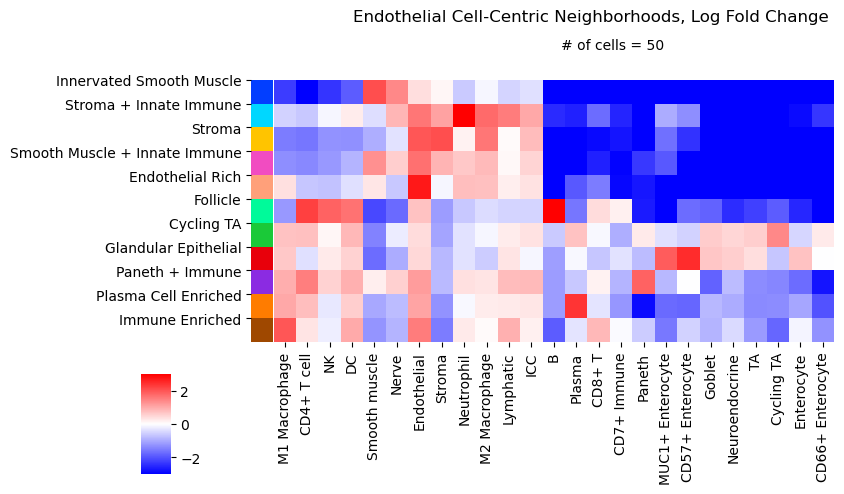

In [25]:
# #this plot shows the types of cells (ClusterIDs) in the different niches (0-9)
# k_to_plot = k
# niche_clusters = (k_centroids[k_to_plot])
# tissue_avgs = values.mean(axis = 0)
# fc = np.log2(((niche_clusters+tissue_avgs)/(niche_clusters+tissue_avgs).sum(axis = 1, keepdims = True))/tissue_avgs)
# fc = pd.DataFrame(fc,columns = sum_cols)
s=sns.clustermap(fc_comb, vmin =-3,vmax = 3,cmap = 'bwr', figsize=(10,5), row_colors=[endo_data.reindex(fc_comb.index)['color']])
s.ax_row_dendrogram.set_visible(False)
s.ax_col_dendrogram.set_visible(False)

y_axis_ = s.dendrogram_row.reordered_ind
x_axis_ = s.dendrogram_col.reordered_ind
x_axis_labels_endo = fc_output.columns[x_axis_]
y_axis_labels_endo = fc_comb.index[y_axis_]
print(y_axis_labels_endo)

heatmap_ax = s.ax_heatmap
heatmap_ax.set_yticklabels([])
heatmap_ax.set_ylabel('')
heatmap_ax.set_yticks([])

# Add y-axis labels to the row_colors axis
row_colors_ax = s.ax_row_colors
row_colors_ax.set_yticks(np.linspace(0, 10, len(fc_comb)))
row_colors_ax.set_yticklabels(y_axis_labels_endo)  # or your custom labels
row_colors_ax.yaxis.set_ticks_position('left')
row_colors_ax.yaxis.set_label_position('left')
row_colors_ax.tick_params(axis='y', labelsize=10)  # you can control font size

# colorbar
cbar_ax = s.cax
cbar_ax.set_position([0.05, 0.05, 0.03, 0.2])

s.fig.suptitle('Endothelial Cell-Centric Neighborhoods, Log Fold Change')

s.fig.text(x=0.47, y=0.90, s = titlename)

#### UMAP visualization - cell type

In [26]:
type_cells['neigh_str'] = type_cells['neighborhood'+str(k)].astype(str)
type_cells_merged['neigh_str'] = type_cells_merged['neighborhood'+str(k)].astype(str)

In [27]:
markerlist = [
 'tissue', 'donor', 'region', 'Xcorr', 'Ycorr',
       'Tissue_location', 'array', 'Cell Type', 'Cell subtype', # 'neighborhood50_merged',
       'Neighborhood', 'Neighborhood_Ind', 'Neigh_sub',
       'NeighInd_sub', 'Community', 'Major Community', 'Tissue Segment'
]

In [28]:
#Add in markers for potential clustering later
markerlist.append('neighborhood'+str(k))
#markerlist.append('day harvested')

# marker_df = type_cells[markerlist] # use type_cells for unmerged clusters
marker_df = type_cells_merged[markerlist]


#turn into dictionary so I can extract values later for dataframe
tfc = fc.T

#key 1 is neighborhood number, #key 2 is the cell type
dict_tfc = tfc.to_dict()

#Map back with neighborhood number
for cell_type_unique in dict_tfc[0].keys():
    marker_df[str('Enriched ')+cell_type_unique] = marker_df['neighborhood'+str(k)].apply(lambda x:dict_tfc[x][cell_type_unique])



In [29]:
comb_df = pd.concat([celltype_windows, marker_df], axis=1)


In [30]:
#Read in Data and Rename ClusterID with Named Values
df = comb_df.copy()
#make neighborhood not an integer
df['neighborhood'+str(k)] = df['neighborhood'+str(k)].astype(str)

In [31]:
cell_enr = [
 'Enriched NK', 'Enriched Enterocyte',
       'Enriched CD66+ Enterocyte', 'Enriched TA',
       'Enriched MUC1+ Enterocyte',
       'Enriched Smooth muscle', 'Enriched Paneth', 'Enriched M1 Macrophage',
       'Enriched Goblet', 'Enriched Neuroendocrine',
       'Enriched CD57+ Enterocyte', 'Enriched Lymphatic', 'Enriched CD8+ T',
       'Enriched DC', 'Enriched M2 Macrophage', 'Enriched B',
       'Enriched Neutrophil', 'Enriched Endothelial', 'Enriched Cycling TA',
       'Enriched Plasma', 'Enriched CD4+ T cell', 'Enriched Stroma',
       'Enriched Nerve', 'Enriched ICC', 'Enriched CD7+ Immune',
]


collist = [
'x', 'y', 'unique_region', 'Cell Type','tissue',
       'donor', 'region', 'Xcorr', 'Ycorr', 'Tissue_location', 'array',
       'Cell subtype', 'Neighborhood', 'Neighborhood_Ind', 'neighborhood50',
       'Neigh_sub', 'NeighInd_sub', 'Community', 'Major Community',
       'Tissue Segment'
 ]

#Prepare for making into anndata format so that obs and data are separate
windows_list = [
 'NK', 'Enterocyte',
       'CD66+ Enterocyte', 'TA', 'MUC1+ Enterocyte',
       'Smooth muscle', 'Paneth', 'M1 Macrophage', 'Goblet', 'Neuroendocrine',
       'CD57+ Enterocyte', 'Lymphatic', 'CD8+ T', 'DC', 'M2 Macrophage', 'B',
       'Neutrophil', 'Endothelial', 'Cycling TA', 'Plasma', 'CD4+ T cell',
       'Stroma', 'Nerve', 'ICC', 'CD7+ Immune']

In [32]:
df1 = df.drop(columns = collist ) #USER INPUT

#Prepare for making into anndata format
dfw = df1[windows_list]

In [33]:
#Convert to anndata format
adata_w = sc.AnnData(dfw)
collist.extend(cell_enr)

adata_w.obs = df[collist]

In [34]:
sc.settings.set_figure_params(dpi=80, facecolor='white',dpi_save=300, transparent=True, frameon=False, fontsize=22)
plt.rcParams["legend.markerscale"] = 1

In [35]:
# Merge Clusters
# Cluster annotations based on k=50 and n=20

neighborhood_name_merged = neighborhood_name + '_merged'
merged_nbhds = {'0':'Endothelial Rich',
                '1':'Plasma Cell Enriched',
                '2':'Stroma + Innate Immune',
                '3':'Innervated Smooth Muscle',
                '4':'Immune Enriched',
                '5':'Immune Enriched',
                '6':'Follicle',
                '7':'Cycling TA',
                '8':'Smooth Muscle + Innate Immune',
                '9':'Stroma',
                '10':'Glandular Epithelial',
                '11':'Plasma Cell Enriched',
                '12':'Immune Enriched',
                '13':'Stroma',
                '14':'Smooth Muscle + Innate Immune',
                '15':'Paneth + Immune',
                '16':'Cycling TA',
                '17':'Smooth Muscle + Innate Immune',
                '18':'Glandular Epithelial',
                '19':'Stroma'
                }
adata_w.obs['neighborhood50_merged'] = adata_w.obs['neighborhood50'].replace(merged_nbhds)
# type_cells_merged.to_csv('type_cells_merged.csv', index=False)
# adata_w.obs['neighborhood50_merged']
print(adata_w.obs['neighborhood50_merged'].unique())

['Plasma Cell Enriched' 'Cycling TA' 'Glandular Epithelial'
 'Paneth + Immune' 'Immune Enriched' 'Smooth Muscle + Innate Immune'
 'Endothelial Rich' 'Stroma' 'Stroma + Innate Immune'
 'Innervated Smooth Muscle' 'Follicle']


In [36]:
adata_w

AnnData object with n_obs × n_vars = 187420 × 25
    obs: 'x', 'y', 'unique_region', 'Cell Type', 'Cell Type', 'tissue', 'donor', 'region', 'Xcorr', 'Ycorr', 'Tissue_location', 'array', 'Cell subtype', 'Neighborhood', 'Neighborhood', 'Neighborhood_Ind', 'neighborhood50', 'Neigh_sub', 'NeighInd_sub', 'Community', 'Major Community', 'Tissue Segment', 'Enriched NK', 'Enriched Enterocyte', 'Enriched CD66+ Enterocyte', 'Enriched TA', 'Enriched MUC1+ Enterocyte', 'Enriched Smooth muscle', 'Enriched Paneth', 'Enriched M1 Macrophage', 'Enriched Goblet', 'Enriched Neuroendocrine', 'Enriched CD57+ Enterocyte', 'Enriched Lymphatic', 'Enriched CD8+ T', 'Enriched DC', 'Enriched M2 Macrophage', 'Enriched B', 'Enriched Neutrophil', 'Enriched Endothelial', 'Enriched Cycling TA', 'Enriched Plasma', 'Enriched CD4+ T cell', 'Enriched Stroma', 'Enriched Nerve', 'Enriched ICC', 'Enriched CD7+ Immune', 'neighborhood50_merged'

In [37]:
umap_color_palette = {'Plasma Cell Enriched': (1.0, 0.48627450980392156, 0.0),
 'Cycling TA': (0.10196078431372549, 0.788235294117647, 0.2196078431372549),
 'Glandular Epithelial': (0.9098039215686274, 0.0, 0.043137254901960784),
 'Paneth + Immune': (0.5450980392156862, 0.16862745098039217,0.8862745098039215),
 'Immune Enriched': (0.6235294117647059, 0.2823529411764706, 0.0),
 'Smooth Muscle + Innate Immune': (0.9450980392156862,0.2980392156862745,0.7568627450980392),
 'Endothelial Rich': rgba_lightsalmon,
 'Stroma': (1.0, 0.7686274509803922, 0.0),
 'Stroma + Innate Immune': (0.0, 0.8431372549019608, 1.0),
 'Innervated Smooth Muscle': (0.00784313725490196, 0.24313725490196078, 1.0),
 'Follicle': rgba_mediumspringgreen}

adata_w.uns['neighborhood50_merged_colors'] = umap_color_palette

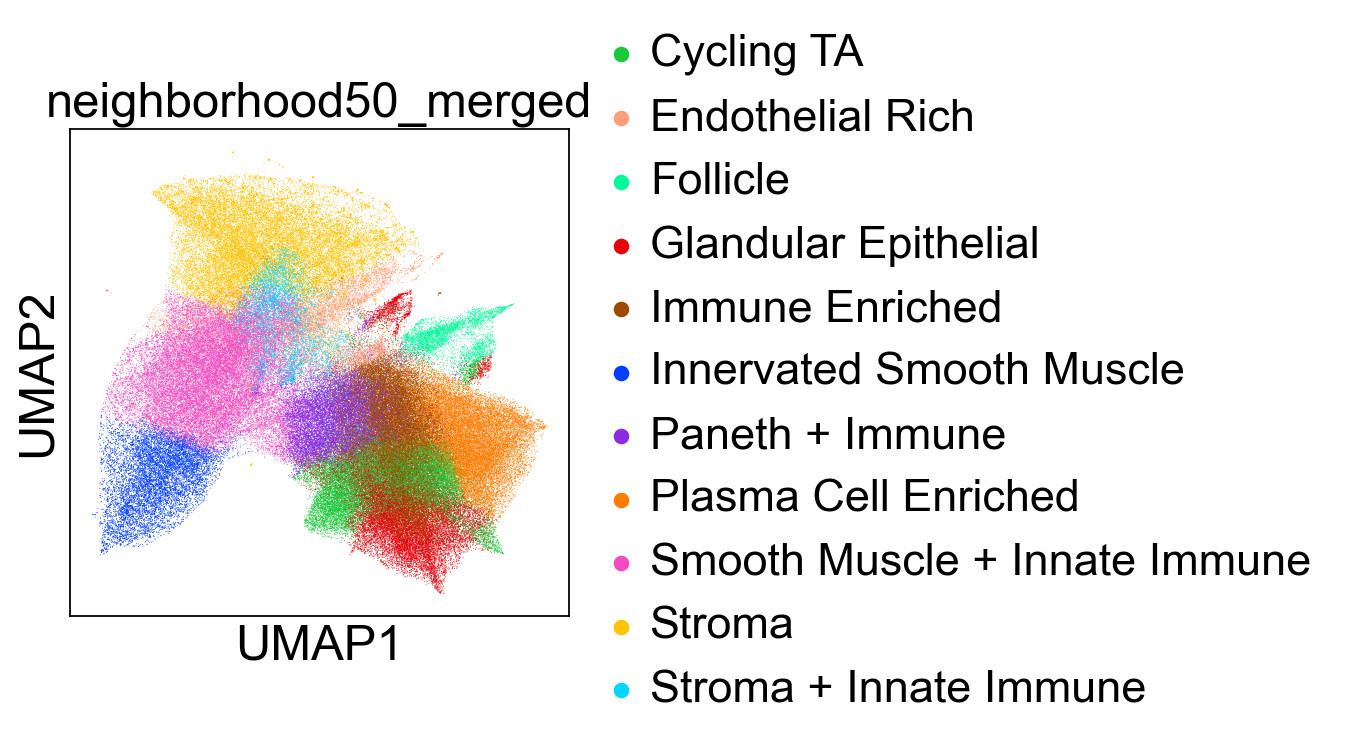

In [38]:
#Compute the neighborhood relations of single cells.
#The size of local neighborhood (in terms of number of neighboring data points) used for
#manifold approximation. Larger values result in more global views of the manifold, while
#smaller values result in more local data being preserved. In general values should be in
#the range 2 to 100 and a good average is 10
#13 is good
sc.pp.neighbors(adata_w, n_neighbors=50)
sc.tl.umap(adata_w)
sc.pl.umap(adata_w, color ='neighborhood50_merged',palette=umap_color_palette, show=True, frameon=True)
# sc.pl.umap(adata_w, color ='Neighborhood',)


In [ ]:
sc.pl.umap(adata_w, color ='Tissue_location',)

In [ ]:
! pip3 install leidenalg

In [ ]:
sc.tl.leiden(adata_w, resolution=0.5)
# sc.tl.leiden(adata_w, resolution=0.5, flavor="igraph", n_iterations=2, directed=False)
sc.pl.umap(adata_w, color ='leiden')


#### Rings Analysis
Generate endothelial cell type-centric neighborhoods  at increasing radii.


In [39]:
os.environ['OMP_NUM_THREADS'] = '4' # For running on Windows with MKL

#Fill in based on above
k = 50
n_neighborhoods = 1
neighborhood_name = "neighborhood"+str(k)
k_centroids = {}

#choose windows with k calculated of interest
windows2 = windows[k]
windows2[cluster_col] = cells[cluster_col]
print(cluster_col)

#Only use T cell windows for example in cell_list
cell_name = 'endothelial cells'
#cell_list = ['Paneth','OLFM4+ Enterocyte']
cell_list = ['Endothelial']
celltype_windows = windows2[windows2[cluster_col].isin(cell_list)]
type_cells = cells[cells[cluster_col].isin(cell_list)]

#Add lables
km = MiniBatchKMeans(n_clusters = n_neighborhoods,random_state=0)
labels = km.fit_predict(celltype_windows[sum_cols].values)
k_centroids[k] = km.cluster_centers_
type_cells[neighborhood_name] = labels

#Get out heat
k_to_plot = k
niche_clusters = (k_centroids[k_to_plot])
tissue_avgs = values.mean(axis = 0)
fc = np.log2(((niche_clusters+tissue_avgs)/(niche_clusters+tissue_avgs).sum(axis = 1, keepdims = True))/tissue_avgs)
fc = pd.DataFrame(fc,columns = sum_cols)
fc_output = fc.rename(index={0:k})


Cell Type


In [40]:
# wrapped function to calculate fold change and neighborhood averages
def fc_out(data, k_num, nbhd):
    #Fill in based on above
    k = k_num
    n_neighborhoods = 1
    neighborhood_name = "neighborhood"+str(k)
    k_centroids = {}

    #choose windows with k calculated of interest
    windows2 = windows[k]
    windows2[cluster_col] = data[cluster_col]
    windows2['Endothelial Neighborhood'] = data['Endothelial Neighborhood']

    #Only use T cell windows for example in cell_list
    cell_name = 'endothelial cells'
    #cell_list = ['Paneth','OLFM4+ Enterocyte']
    cell_list = ['Endothelial']
    nbhd_list = [nbhd]
    celltype_windows = windows2[windows2[cluster_col].isin(cell_list)]
    type_data = data[data[cluster_col].isin(cell_list)]


    # Endothelial cell-specific
    nbhd_name = 'Endothelial Neighborhood'
    celltype_windows_nbhd = windows2[windows2[nbhd_name].isin(nbhd_list)] # for neighborhood rings analysis, otherwise use celltype_windows
    type_data_nbhd = data[data[nbhd_name].isin(nbhd_list)] # for neighborhood rings analysis, otherwise use type_data

    #Add labels
    km = MiniBatchKMeans(n_clusters = n_neighborhoods,random_state=0)

    labels = km.fit_predict(celltype_windows_nbhd[sum_cols].values)
    k_centroids[k] = km.cluster_centers_
    type_data_nbhd[neighborhood_name] = labels

    #Get out heat
    k_to_plot = k
    niche_clusters = (k_centroids[k_to_plot])
    tissue_avgs = values.mean(axis = 0)
    fc = np.log2(((niche_clusters+tissue_avgs)/(niche_clusters+tissue_avgs).sum(axis = 1, keepdims = True))/tissue_avgs)
    fc = pd.DataFrame(fc,columns = sum_cols)
    niche_aveg = pd.DataFrame(niche_clusters,columns = sum_cols)
    niche_avegg = niche_aveg/niche_aveg.sum(axis=1)[0]*100

    fc_output = fc.rename(index={0:k})
    niche_out = niche_avegg.rename(index={0:k})
    return fc_output, niche_out

In [41]:
# Copy of cells dataframe with endothelial cell-centric neighborhood column
cells_copy_rings = cells.copy()
cells_copy_rings.loc[type_cells.index, 'Endothelial Neighborhood'] = type_cells_merged[neighborhood_name_merged]

In [42]:
# Calculate concentric increasing neighborhoods for endothelial cells
os.environ['OMP_NUM_THREADS'] = '4' # For running on Windows with MKL

fc_list = []
fc_comb_list = []
niche_list = []
niche_comb_list = []
single_nbhd_list = []

for single_nbhd in y_axis_labels_endo: # same order as heatmap above
    single_nbhd_list.append(single_nbhd)
    for kn in ks:
        df1, df2 = fc_out(data=cells_copy_rings, k_num=kn, nbhd = single_nbhd) # df1 is fc_output, df2 is niche_out
        new_neigh = 'neighborhood'+str(kn)
        df1['Endothelial Neighborhood'] = single_nbhd
        df2['Endothelial Neighborhood'] = single_nbhd
        fc_list.append(df1)
        niche_list.append(df2)

    fc_comb = pd.concat(fc_list)

    niche_comb=pd.concat(niche_list)

    fc_comb_list.append(fc_comb)
    niche_comb_list.append(niche_comb)
    
print('Order of neighborhoods:', single_nbhd_list)

Order of neighborhoods: ['Innervated Smooth Muscle', 'Stroma + Innate Immune', 'Stroma', 'Smooth Muscle + Innate Immune', 'Endothelial Rich', 'Follicle', 'Cycling TA', 'Glandular Epithelial', 'Paneth + Immune', 'Plasma Cell Enriched', 'Immune Enriched']


In [43]:
plt.style.use(['default'])
#GENERAL GRAPH SETTINGs
#font size of graph
SMALL_SIZE = 14
MEDIUM_SIZE = 16
BIGGER_SIZE = 18

#Settings for graph
plt.rc('font', size=SMALL_SIZE)          # controls default text sizes
plt.rc('axes', titlesize=SMALL_SIZE)     # fontsize of the axes title
plt.rc('axes', labelsize=MEDIUM_SIZE)    # fontsize of the x and y labels
plt.rc('xtick', labelsize=SMALL_SIZE)    # fontsize of the tick labels
plt.rc('ytick', labelsize=SMALL_SIZE)    # fontsize of the tick labels
plt.rc('legend', fontsize=SMALL_SIZE)    # legend fontsize
plt.rc('figure', titlesize=BIGGER_SIZE)  # fontsize of the figure title

In [44]:
# Row colors for the clustermap
fc_comb_plot = fc_comb[x_axis_labels_endo]
niche_comb_plot = niche_comb[x_axis_labels_endo]
rings_row_colors = fc_comb['Endothelial Neighborhood'].map(endo_data['color'])

y_axis_labels_endo_multiple = list(fc_comb['Endothelial Neighborhood'].values)

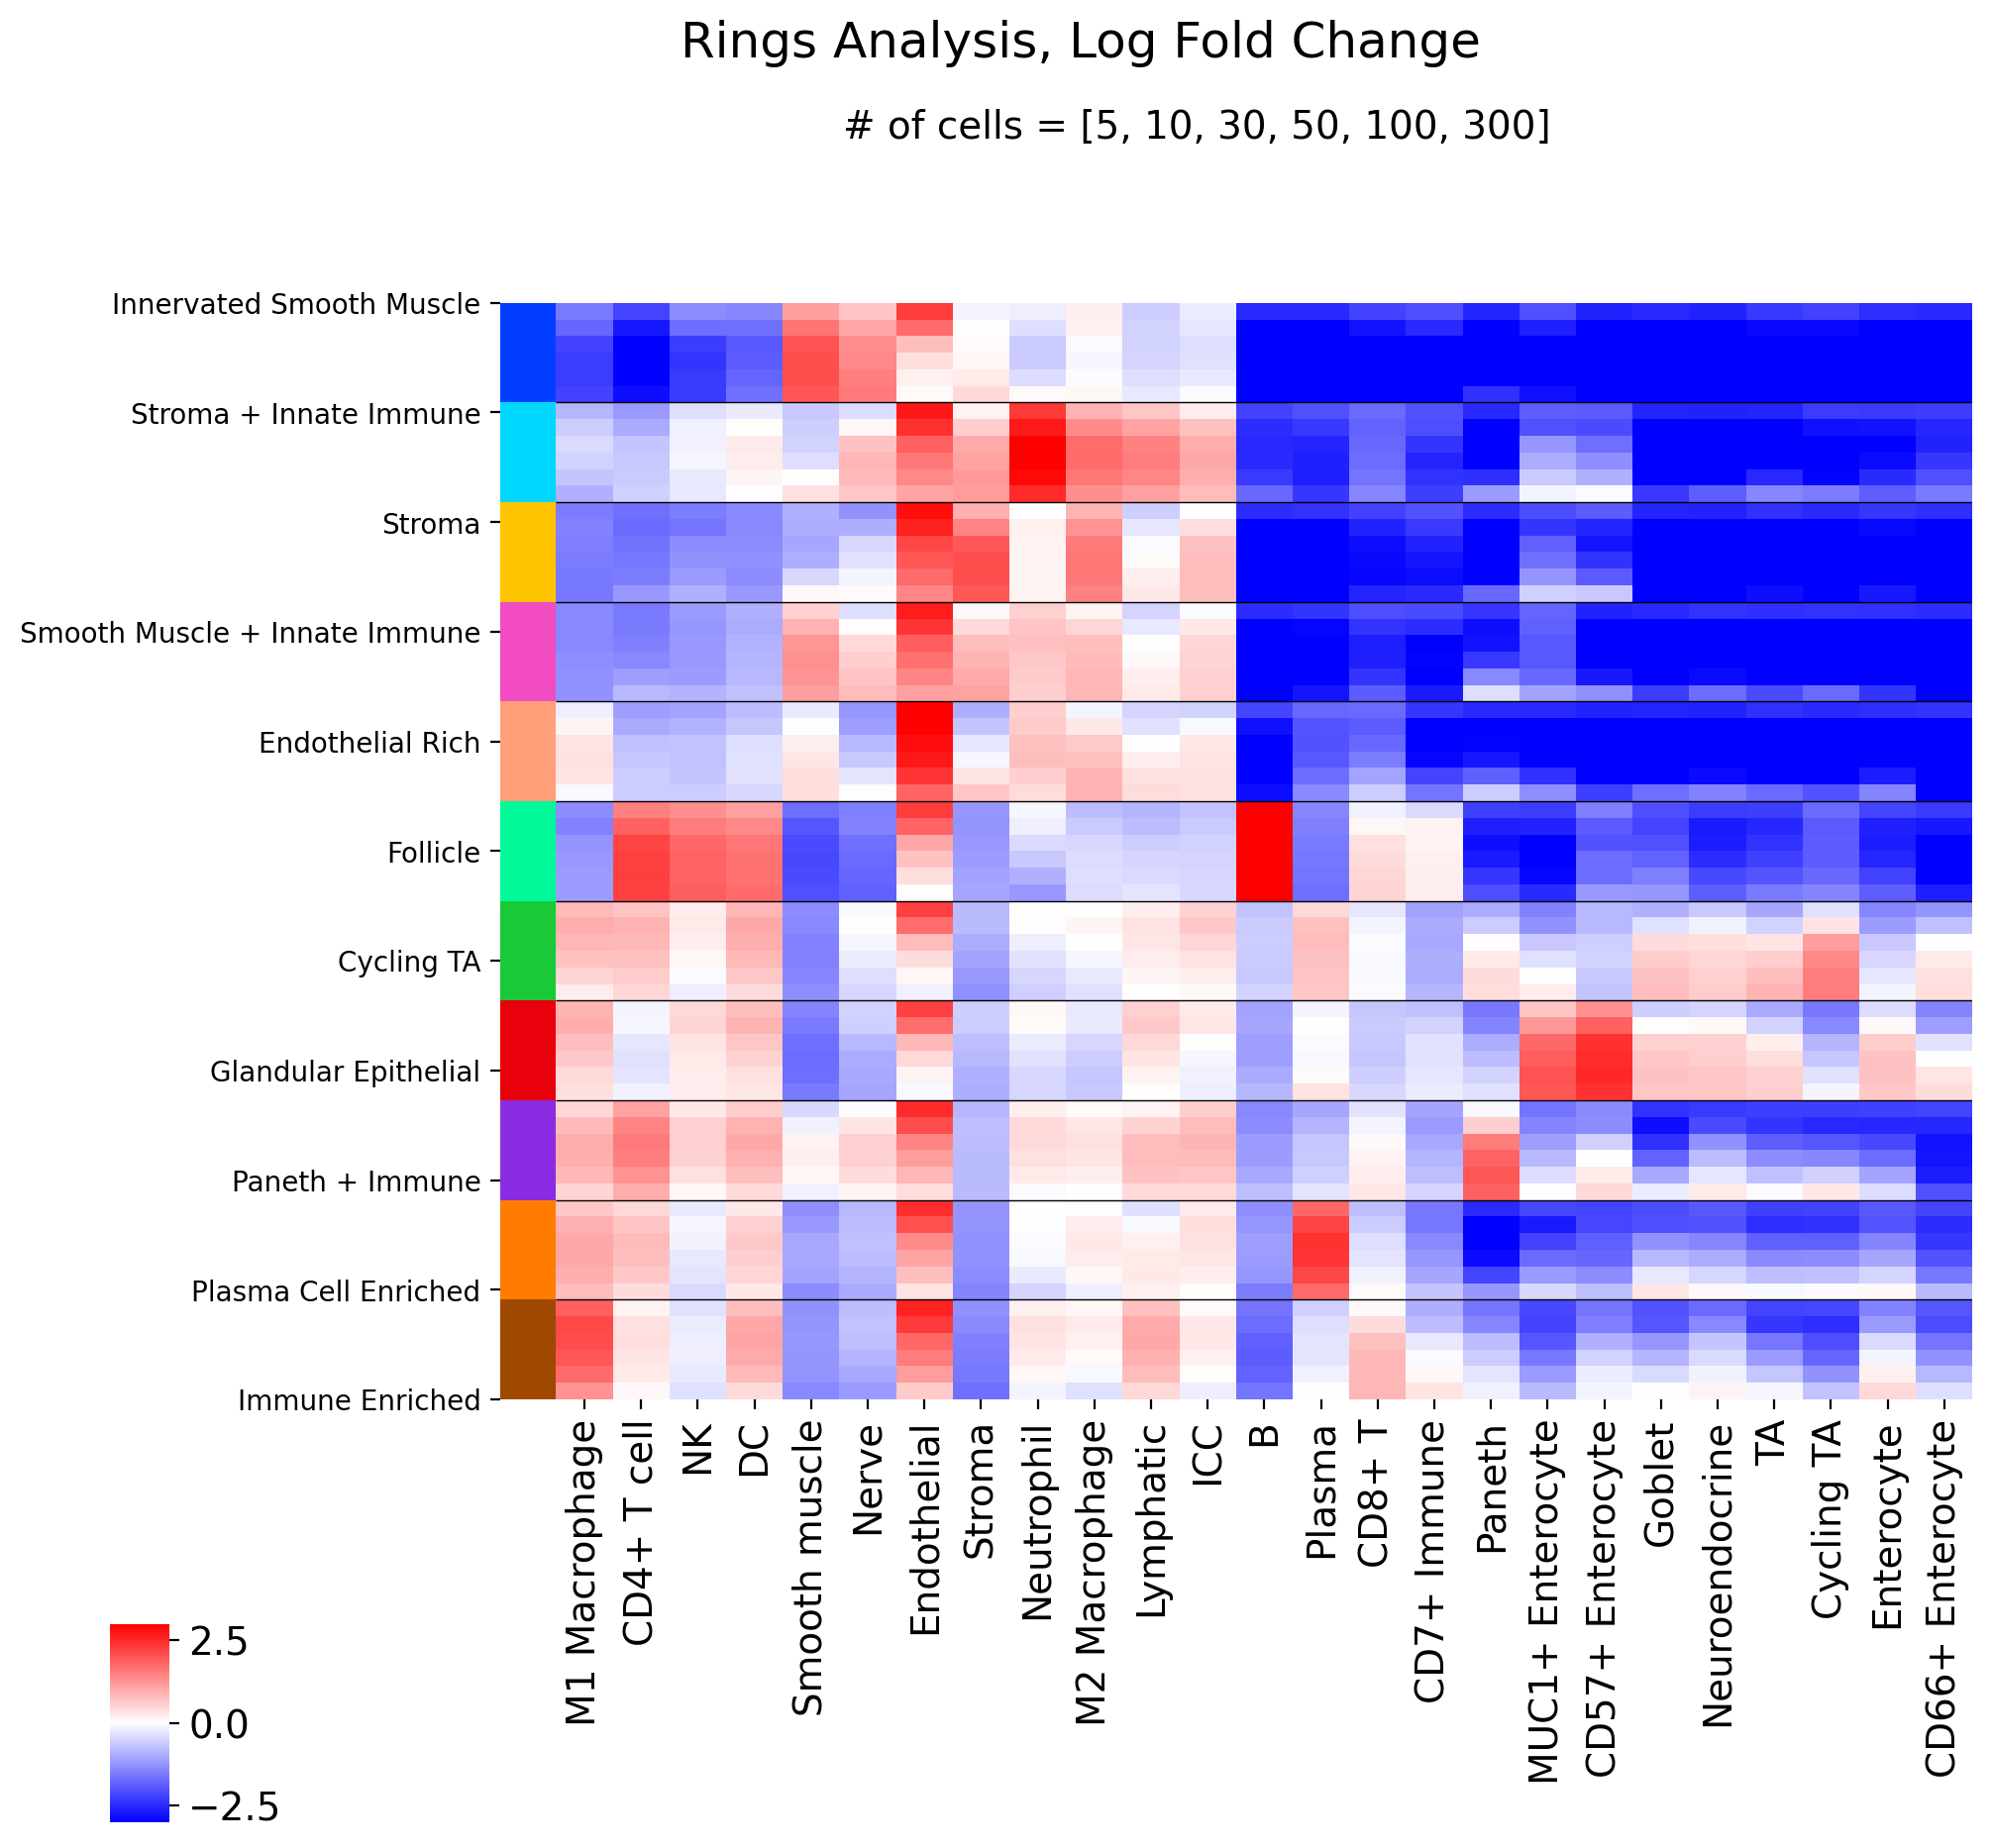

In [45]:
# looking at log fold change enrichment
s=sns.clustermap(fc_comb_plot, vmin =-3,vmax = 3,cmap = 'bwr', figsize=(10,10),cbar_pos=(0.01,0.07,0.03,0.1), row_cluster=False, col_cluster=False, row_colors=rings_row_colors)
s.ax_row_dendrogram.set_visible(False)
s.ax_col_dendrogram.set_visible(False)
s.fig.suptitle('Rings Analysis, Log Fold Change')
s.fig.text(x=0.38, y=0.92, s = '# of cells = ' + str(ks))

heatmap_ax = s.ax_heatmap
# heatmap_ax.set_yticks(np.arange(0, fc_comb.shape[0] , 6))  # Set tick positions
heatmap_ax.hlines(np.arange(6, len(fc_comb_plot), 6), *heatmap_ax.get_xlim(),color="black", linestyle="-", linewidth=0.5)
heatmap_ax.set_yticklabels([])
heatmap_ax.set_ylabel('')
heatmap_ax.set_yticks([])
# heatmap_ax.set_yticklabels(y_axis_labels_endo_multiple[::6], rotation=0)
# s.ax_heatmap.yaxis.set_ticks_position("hide")

# Add y-axis labels to the row_colors axis
row_colors_ax = s.ax_row_colors
row_colors_ax.tick_params(axis='x', bottom=False, labelbottom=False)
row_colors_ax.set_yticks(np.linspace(66, 0, int(len(fc_comb_plot)/len(ks))))
row_colors_ax.set_yticklabels(y_axis_labels_endo_multiple[::6][::-1])  # or your custom labels
row_colors_ax.yaxis.set_ticks_position('left')
row_colors_ax.yaxis.set_label_position('left')
row_colors_ax.tick_params(axis='y', labelsize=10)  # you can control font size

# plt.savefig(save_path+'Endothelial_cell_enrichment.png', format='png', dpi=300, transparent=True, bbox_inches='tight')

[Text(1, 0, 'Innervated Smooth Muscle'),
 Text(1, 6, 'Stroma + Innate Immune'),
 Text(1, 12, 'Stroma'),
 Text(1, 18, 'Smooth Muscle + Innate Immune'),
 Text(1, 24, 'Endothelial Rich'),
 Text(1, 30, 'Follicle'),
 Text(1, 36, 'Cycling TA'),
 Text(1, 42, 'Glandular Epithelial'),
 Text(1, 48, 'Paneth + Immune'),
 Text(1, 54, 'Plasma Cell Enriched'),
 Text(1, 60, 'Immune Enriched')]

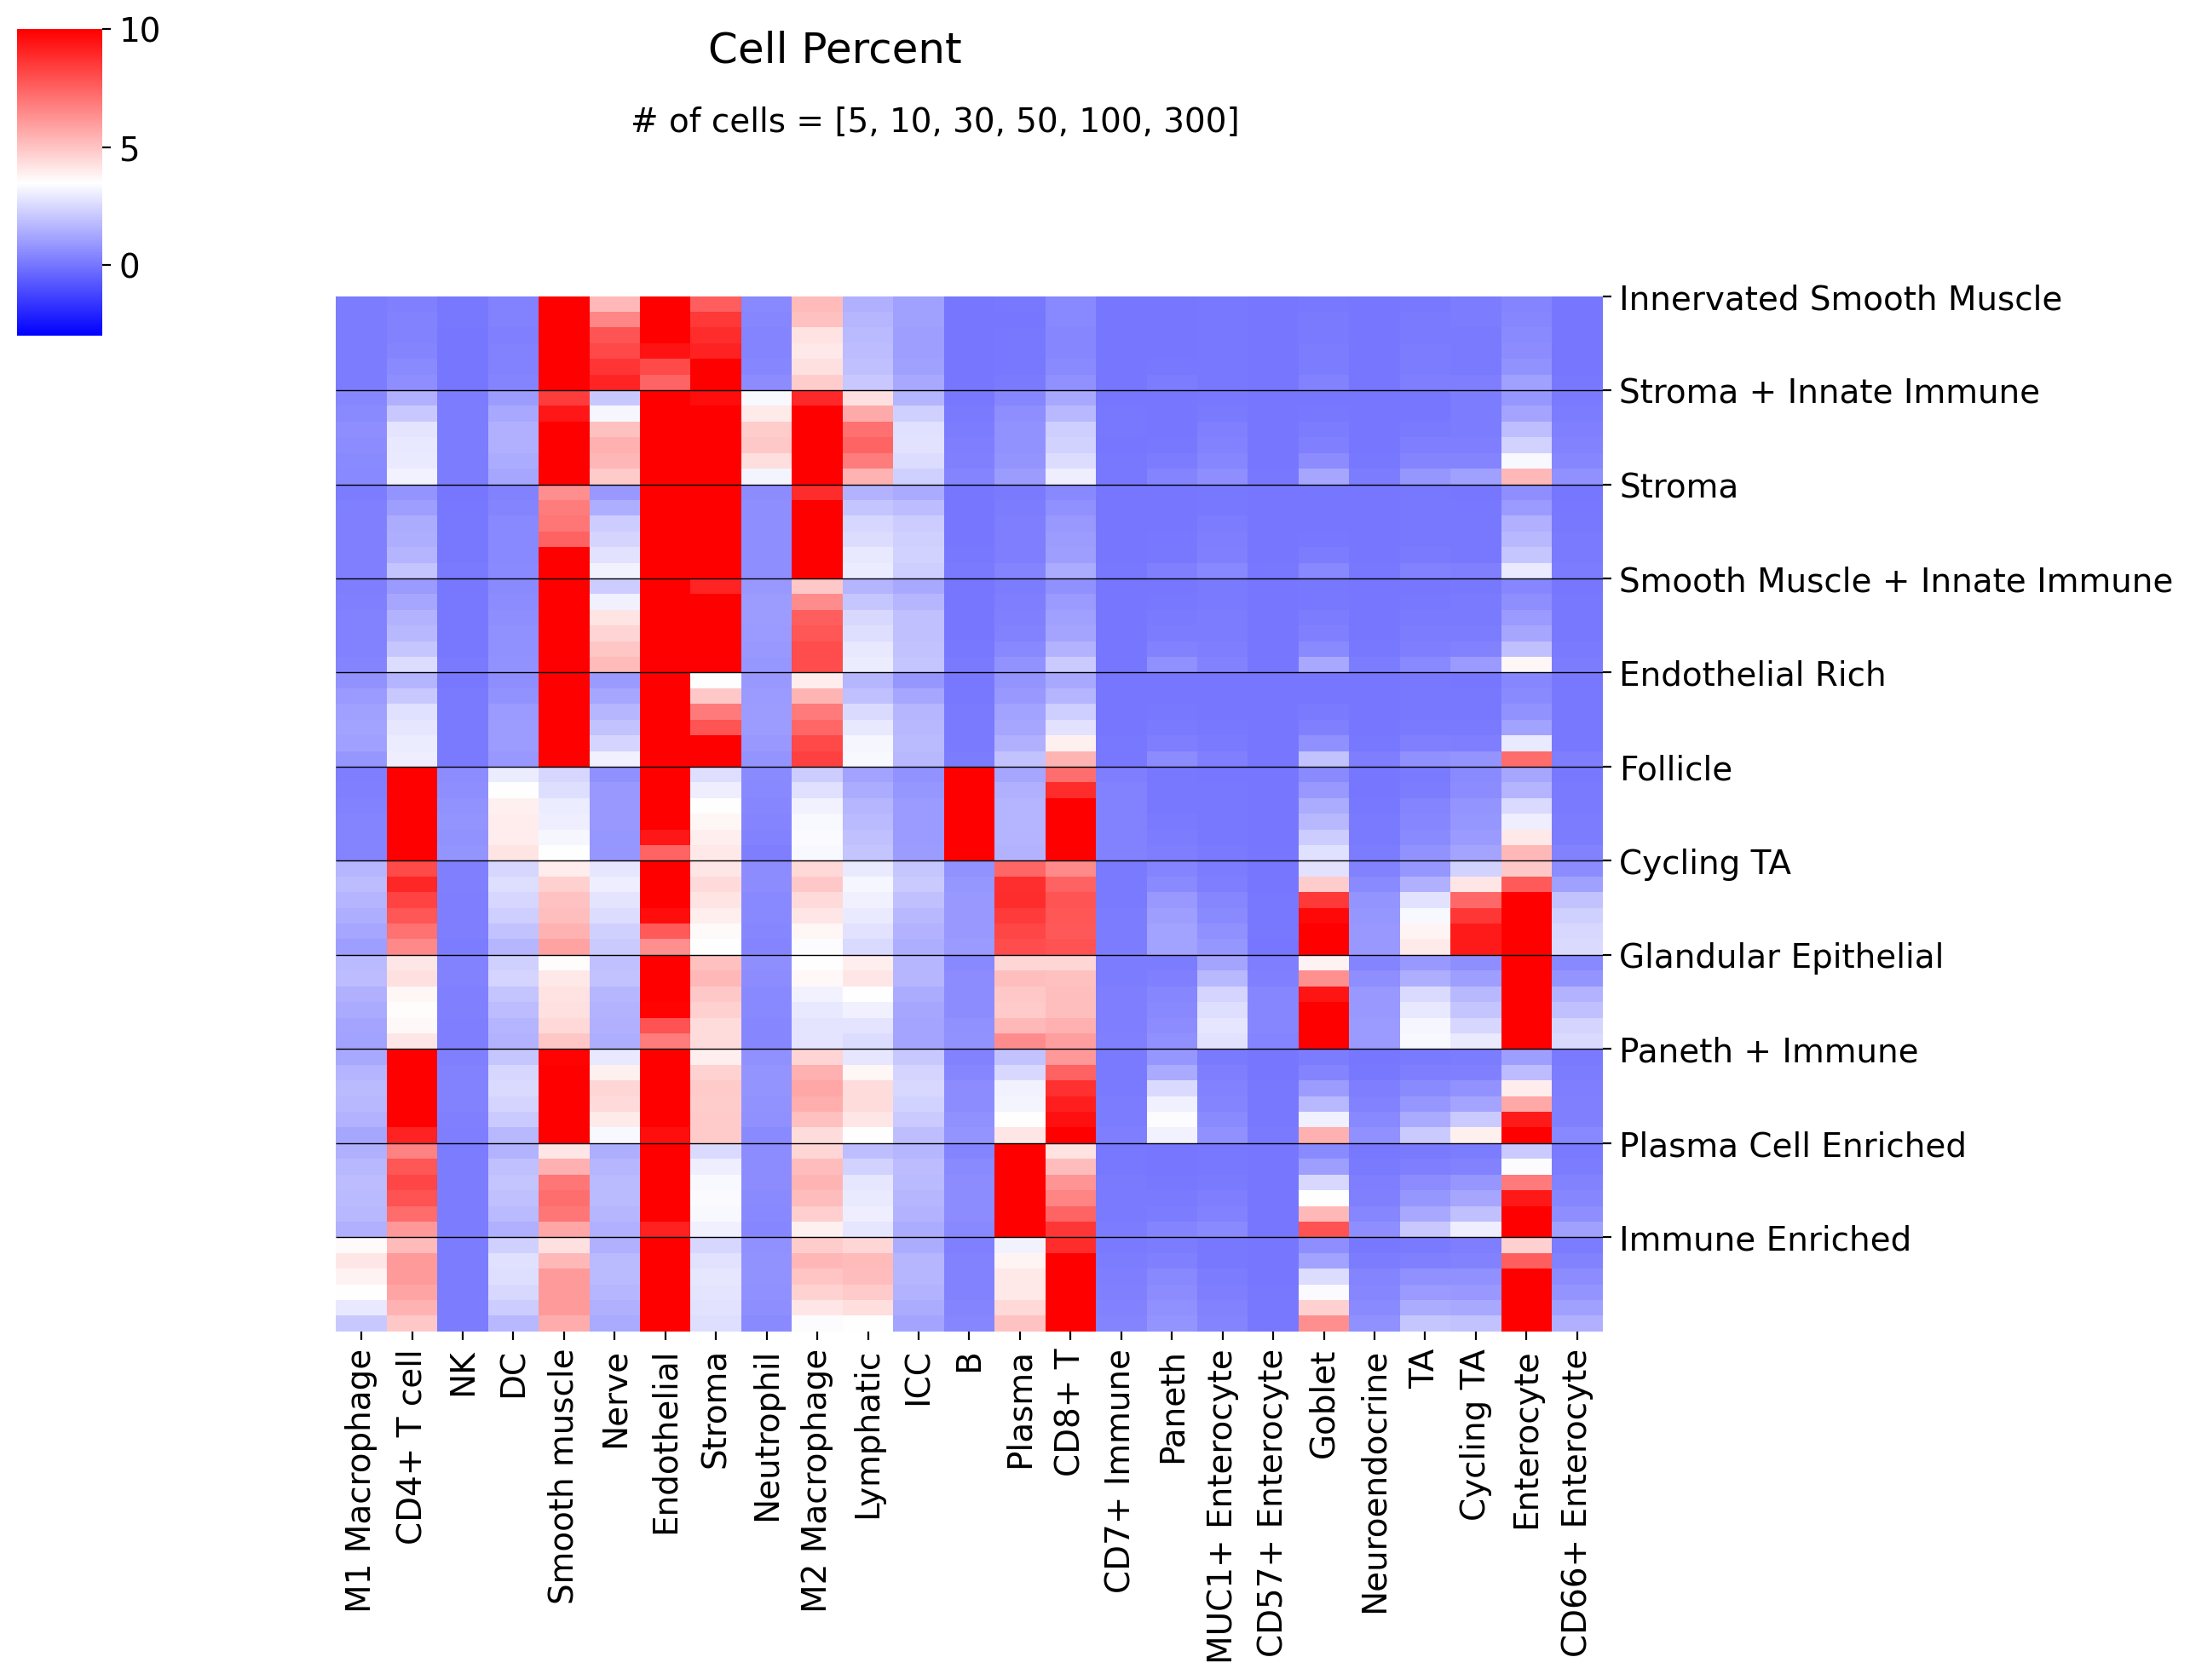

In [46]:
# looking at cell percentage as compared to total number of cells across all tissues
s=sns.clustermap(niche_comb_plot, vmin=-3,vmax=10, cmap = 'bwr', figsize=(10,10), row_cluster=False, col_cluster=False)
s.ax_row_dendrogram.set_visible(False)
s.ax_col_dendrogram.set_visible(False)
s.fig.suptitle('Cell Percent')
s.fig.text(x=0.38, y=0.92, s = '# of cells = '+ str(ks))

heatmap_ax = s.ax_heatmap
heatmap_ax.set_yticks(np.arange(0, niche_comb_plot.shape[0] , 6))  # Set tick positions
heatmap_ax.hlines(np.arange(6, len(niche_comb_plot), 6), *heatmap_ax.get_xlim(),color="black", linestyle="-", linewidth=0.5)
heatmap_ax.set_yticklabels(y_axis_labels_endo_multiple[::6], rotation=0)
# plt.savefig(save_path+'Endothelial_cell_percent.png', format='png', dpi=300, transparent=True, bbox_inches='tight')

In [47]:
nbhd_size = 300
nbhdsize_niche = niche_comb.loc[nbhd_size]
endo_nbhdsize_label = nbhdsize_niche['Endothelial Neighborhood'].values
endo_nbhdsize_niche = nbhdsize_niche['Endothelial'].values

In [48]:
# Average percent enrichment of endothelial cells in each subregion
zipped_endo = zip(endo_nbhdsize_label, endo_nbhdsize_niche)
endo_nbhdsize_dict = dict(zipped_endo)
print(endo_nbhdsize_dict)
muscularisexterna_keys = ['Innervated Smooth Muscle', 'Smooth Muscle + Innate Immune']
submucosa_keys = ['Stroma + Innate Immune', 'Stroma', 'Endothelial Rich']
mucosa_keys = ['Immune Enriched', 'Follicle', 'Glandular Epithelial', 'Paneth + Immune', 'Cycling TA', 'Plasma Cell Enriched']

muscularisexterna_values = [endo_nbhdsize_dict[k] for k in muscularisexterna_keys if k in endo_nbhdsize_dict]
submucosa_values = [endo_nbhdsize_dict[k] for k in submucosa_keys if k in endo_nbhdsize_dict]
mucosa_values = [endo_nbhdsize_dict[k] for k in mucosa_keys if k in endo_nbhdsize_dict]
muscularisexterna_average = sum(muscularisexterna_values) / len(muscularisexterna_values)
submucosa_average = sum(submucosa_values) / len(submucosa_values)
mucosa_average = sum(mucosa_values) / len(mucosa_values)
print(muscularisexterna_average)

{'Innervated Smooth Muscle': 7.460700757575757, 'Stroma + Innate Immune': 15.079216452205884, 'Stroma': 19.284672619047623, 'Smooth Muscle + Innate Immune': 15.53073459201389, 'Endothelial Rich': 25.267686631944443, 'Follicle': 7.429389105902777, 'Cycling TA': 6.354373816287878, 'Glandular Epithelial': 6.811016007965685, 'Paneth + Immune': 9.596267361111112, 'Plasma Cell Enriched': 9.142111545138889, 'Immune Enriched': 11.13879180372807}
11.495717674794824


Text(0.5, 1.0, 'EC Percentage per Neighborhood 300')

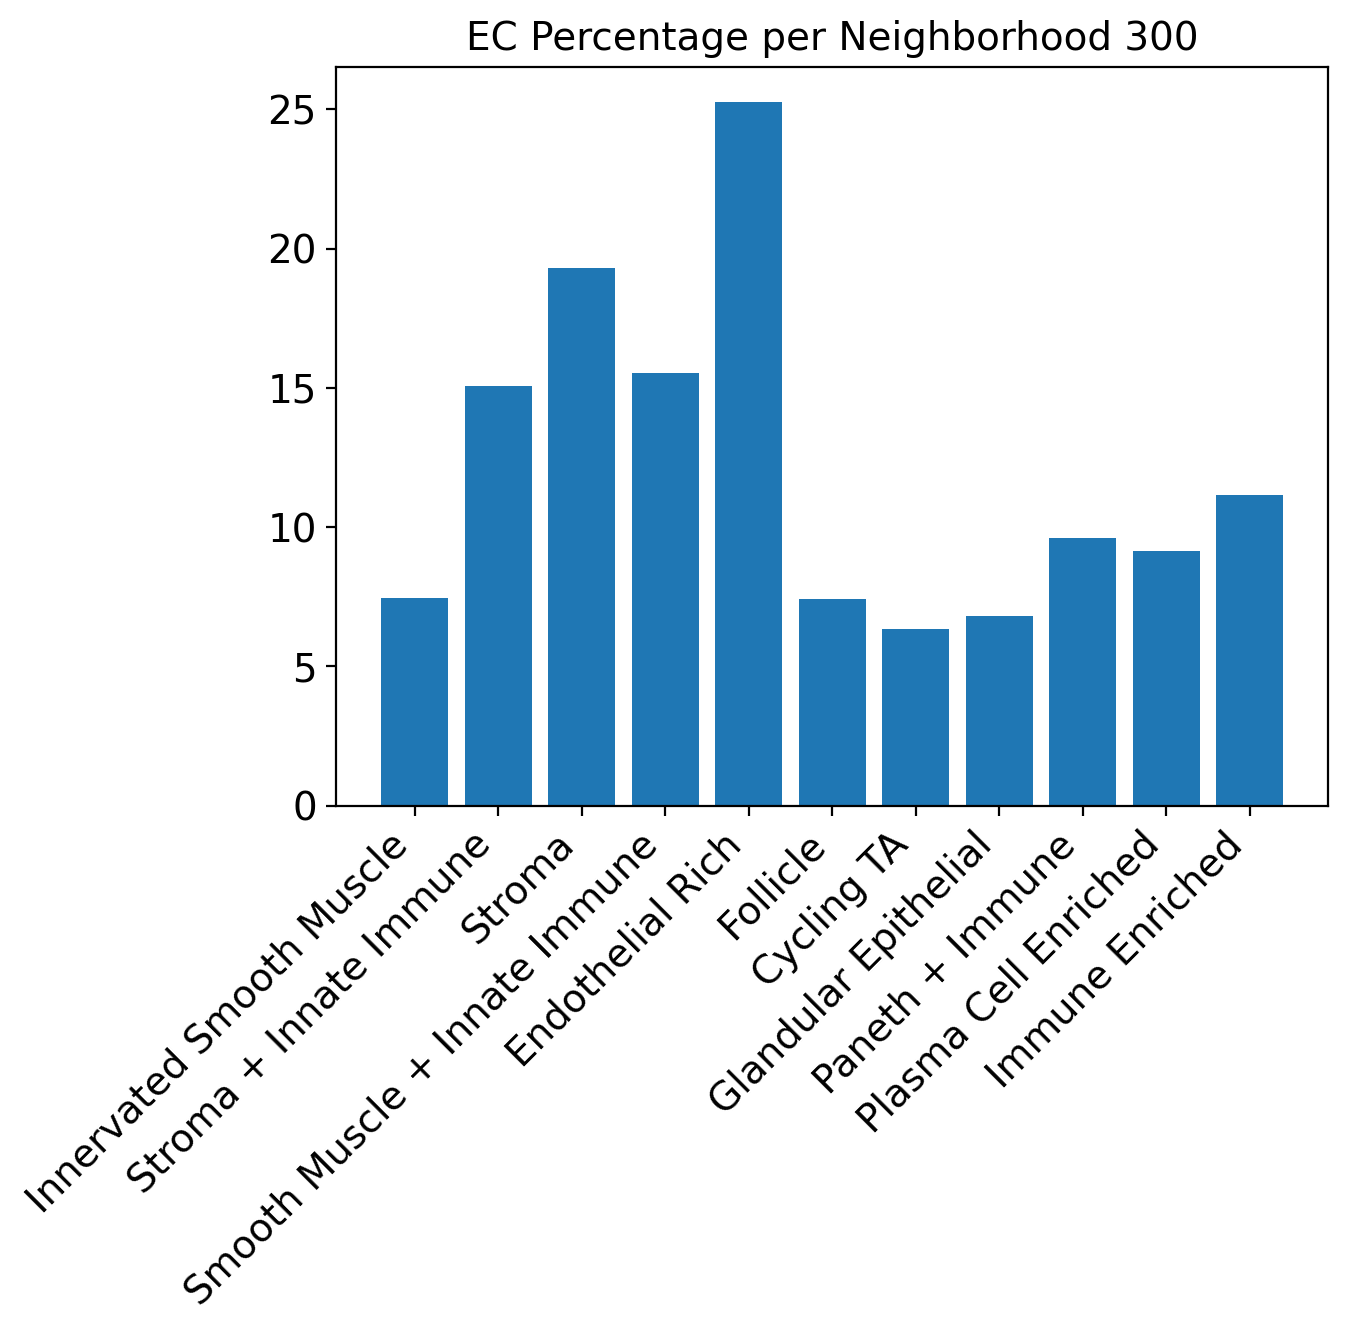

In [49]:
plt.bar(endo_nbhdsize_label,endo_nbhdsize_niche)
plt.xticks(rotation=45, ha='right')
plt.title('EC Percentage per Neighborhood ' + str(nbhd_size))

In [ ]:
niche_comb_CyclingTA = niche_comb[niche_comb['Endothelial Neighborhood'] == 'Cycling TA']
niche_comb_CyclingTA = niche_comb_CyclingTA.drop(columns=['Endothelial Neighborhood'])

In [ ]:
# Cycling TA
s=sns.clustermap(niche_comb_CyclingTA, vmin=-3, vmax=15, cmap = 'bwr', figsize=(10,5), row_cluster=False)
s.ax_row_dendrogram.set_visible(False)
s.ax_col_dendrogram.set_visible(False)

In [ ]:
cell_map = {
    'NK': 'blue',
 'Enterocyte': 'magenta',
 'MUC1+ Enterocyte': 'mediumspringgreen',
 'TA': 'skyblue',
 'CD66+ Enterocyte': 'darkorange',
 'Paneth': 'green',
 'Smooth muscle': 'red',
 'Cycling TA': 'tan',
 'M1 Macrophage': 'gray',
 'Goblet': 'indigo',
 'Neuroendocrine': 'yellowgreen',
 'CD57+ Enterocyte': 'lightsalmon',
 'Lymphatic': 'plum',
 'CD8+ T': 'gold',
 'DC': 'blueviolet',
 'M2 Macrophage': 'bisque',
 'B': 'navy',
 'Neutrophil': 'goldenrod',
 'Endothelial': 'black',
 'Plasma': 'yellow',
 'CD4+ T cell': 'brown',
 'Stroma': 'dimgray',
 'Nerve': 'olive',
 'ICC': 'teal',
 'CD7+ Immune': 'lightcoral'}

In [ ]:
# Cycling TA neighborhood stacked bar plot
niche_comb_CyclingTA.plot(kind='bar', stacked=True,
        title='Cycling TA Neighborhood', figsize=(8.5,5), color = cell_map)
plt.legend(bbox_to_anchor=(1, 1))
plt.xlabel('Neighborhood Size (# of cells)')
plt.xticks(rotation=0.5) 
plt.show()


### Donor-Specific Rings Analysis
Stratify data by donors to analyze EC neighborhood enrichment.

In [50]:
cells_copy_donor_rings = cells.copy()
cells_copy_donor_rings.loc[type_cells.index, 'Endothelial Neighborhood'] = type_cells_merged[neighborhood_name_merged]

In [51]:
# wrapped function to calculate fold change and neighborhood averages for donor rings analysis
def fc_out_ring(data, knums, nbhds):
# Calculate concentric increasing neighborhoods for endothelial cells
    os.environ['OMP_NUM_THREADS'] = '4' # For running on Windows with MKL

    fc_list = []
    fc_comb_list = []
    niche_list = []
    niche_comb_list = []
    single_nbhd_list = []

    for single_nbhd in nbhds: # same order as heatmap above
        single_nbhd_list.append(single_nbhd)
        for kn in knums:
            df1, df2 = fc_out(data=data, k_num=kn, nbhd = single_nbhd) # df1 is fc_output, df2 is niche_out
            new_neigh = 'neighborhood'+str(kn)
            df1['Endothelial Neighborhood'] = single_nbhd
            df2['Endothelial Neighborhood'] = single_nbhd
            fc_list.append(df1)
            niche_list.append(df2)

        fc_comb = pd.concat(fc_list)

        niche_comb=pd.concat(niche_list)

        fc_comb_list.append(fc_comb)
        niche_comb_list.append(niche_comb)
        
    print('Order of neighborhoods:', single_nbhd_list)
    return fc_comb, niche_comb

In [52]:
fc_dict = {}
nc_dict = {}
for donor in cells_copy_donor_rings['donor'].unique():
    cells_copy_dr = cells_copy_donor_rings[cells_copy_donor_rings['donor'] == donor]
    fc, nc = fc_out_ring(cells_copy_dr, ks, y_axis_labels_endo)
    fc['donor'] = donor
    nc['donor'] = donor
    fc_dict[donor] = fc
    nc_dict[donor] = nc

print("List of donors", fc_dict.keys())

Order of neighborhoods: ['Innervated Smooth Muscle', 'Stroma + Innate Immune', 'Stroma', 'Smooth Muscle + Innate Immune', 'Endothelial Rich', 'Follicle', 'Cycling TA', 'Glandular Epithelial', 'Paneth + Immune', 'Plasma Cell Enriched', 'Immune Enriched']
Order of neighborhoods: ['Innervated Smooth Muscle', 'Stroma + Innate Immune', 'Stroma', 'Smooth Muscle + Innate Immune', 'Endothelial Rich', 'Follicle', 'Cycling TA', 'Glandular Epithelial', 'Paneth + Immune', 'Plasma Cell Enriched', 'Immune Enriched']
Order of neighborhoods: ['Innervated Smooth Muscle', 'Stroma + Innate Immune', 'Stroma', 'Smooth Muscle + Innate Immune', 'Endothelial Rich', 'Follicle', 'Cycling TA', 'Glandular Epithelial', 'Paneth + Immune', 'Plasma Cell Enriched', 'Immune Enriched']
Order of neighborhoods: ['Innervated Smooth Muscle', 'Stroma + Innate Immune', 'Stroma', 'Smooth Muscle + Innate Immune', 'Endothelial Rich', 'Follicle', 'Cycling TA', 'Glandular Epithelial', 'Paneth + Immune', 'Plasma Cell Enriched', 'Im

In [53]:
nbhd_size_5 = 5
nbhd_size_300 = 300
ratio_dict = {}
dict_300 = {}
for key in nc_dict.keys():
    donor_nc = nc_dict[key]
    endo_nbhd = donor_nc.loc[nbhd_size_5]['Endothelial Neighborhood'].reset_index(drop=True)
    numerator = donor_nc.loc[nbhd_size_300]['Endothelial'].reset_index(drop=True)
    dict_300[key] = pd.concat([endo_nbhd, numerator], axis=1)
    denominator = donor_nc.loc[nbhd_size_5]['Endothelial'].reset_index(drop=True)
    ratio = numerator/denominator
    ratio_dict[key] = pd.concat([endo_nbhd, ratio], axis=1)

combined_ratio_df = pd.concat(
    [df.assign(Donor=donor) for donor, df in ratio_dict.items()],
    ignore_index=True
)
combined_300_df = pd.concat(
    [df.assign(Donor=donor) for donor, df in dict_300.items()],
    ignore_index=True
)

In [54]:
# Total number of cells in each subregion
total_counts = cells['Tissue Unit'].value_counts()

# Number of endothelial cells in each subregion
endo_counts = cells[cells['Cell Type'] == 'Endothelial']['Tissue Unit'].value_counts()

# Percentage of endothelial cells in each subregion
endo_percent = (endo_counts / total_counts) * 100

# Convert to DataFrame (optional)
endo_percent_df = endo_percent.reset_index()
endo_percent_df.columns = ['Subregion', 'Subregion Endothelial %']
print(endo_percent_df)

# Normalize % EC neighorhood enrichment by tissue subregion
neighborhood_to_subregion = {}

muscularisexterna_keys = ['Innervated Smooth Muscle', 'Smooth Muscle + Innate Immune']
for nbhd in muscularisexterna_keys:
    neighborhood_to_subregion[nbhd] = 'Muscularis externa'
submucosa_keys = ['Stroma + Innate Immune', 'Stroma', 'Endothelial Rich']
for nbhd in submucosa_keys:
    neighborhood_to_subregion[nbhd] = 'Submucosa'
mucosa_keys = ['Immune Enriched', 'Follicle', 'Glandular Epithelial', 'Paneth + Immune', 'Cycling TA', 'Plasma Cell Enriched']
for nbhd in mucosa_keys:
    neighborhood_to_subregion[nbhd] = 'Mucosa'

combined_300_df['Subregion'] = combined_300_df['Endothelial Neighborhood'].map(neighborhood_to_subregion)
combined_300_df = combined_300_df.merge(endo_percent_df, on='Subregion', how='left')
combined_300_df['Normalized Endothelial %'] = combined_300_df['Endothelial'] / combined_300_df['Subregion Endothelial %']
print(combined_300_df)

muscularisexterna_values = [endo_nbhdsize_dict[k] for k in muscularisexterna_keys if k in endo_nbhdsize_dict]
submucosa_values = [endo_nbhdsize_dict[k] for k in submucosa_keys if k in endo_nbhdsize_dict]
mucosa_values = [endo_nbhdsize_dict[k] for k in mucosa_keys if k in endo_nbhdsize_dict]
muscularisexterna_average = sum(muscularisexterna_values) / len(muscularisexterna_values)
submucosa_average = sum(submucosa_values) / len(submucosa_values)
mucosa_average = sum(mucosa_values) / len(mucosa_values)
print(muscularisexterna_average)
combined_300_df

            Subregion  Subregion Endothelial %
0              Mucosa                 5.872435
1  Muscularis externa                 5.591953
2   Muscularis mucosa                 6.887369
3           Submucosa                18.749631
         Endothelial Neighborhood  Endothelial Donor           Subregion  \
0        Innervated Smooth Muscle     7.028422  B004  Muscularis externa   
1          Stroma + Innate Immune    14.471976  B004           Submucosa   
2                          Stroma    18.523835  B004           Submucosa   
3   Smooth Muscle + Innate Immune    14.566749  B004  Muscularis externa   
4                Endothelial Rich    20.402741  B004           Submucosa   
..                            ...          ...   ...                 ...   
83                     Cycling TA     6.286032  B008              Mucosa   
84           Glandular Epithelial     6.647928  B008              Mucosa   
85                Paneth + Immune     8.678890  B008              Mucosa   
86   

,Endothelial Neighborhood,Endothelial,Donor,Subregion,Subregion Endothelial %,Normalized Endothelial %
0,Innervated Smooth Muscle,7.028422,B004,Muscularis externa,5.591953,1.256881
1,Stroma + Innate Immune,14.471976,B004,Submucosa,18.749631,0.771854
2,Stroma,18.523835,B004,Submucosa,18.749631,0.987957
3,Smooth Muscle + Innate Immune,14.566749,B004,Muscularis externa,5.591953,2.604948
4,Endothelial Rich,20.402741,B004,Submucosa,18.749631,1.088168
...,...,...,...,...,...,...
83,Cycling TA,6.286032,B008,Mucosa,5.872435,1.070430
84,Glandular Epithelial,6.647928,B008,Mucosa,5.872435,1.132056
85,Paneth + Immune,8.678890,B008,Mucosa,5.872435,1.477903
86,Plasma Cell Enriched,8.586324,B008,Mucosa,5.872435,1.462140


In [55]:
subregion_palette = {
    'Mucosa': '#1f77b4',      # blue
    'Submucosa': '#2ca02c',   # green
    'Muscularis externa': '#d62728'   # red
}

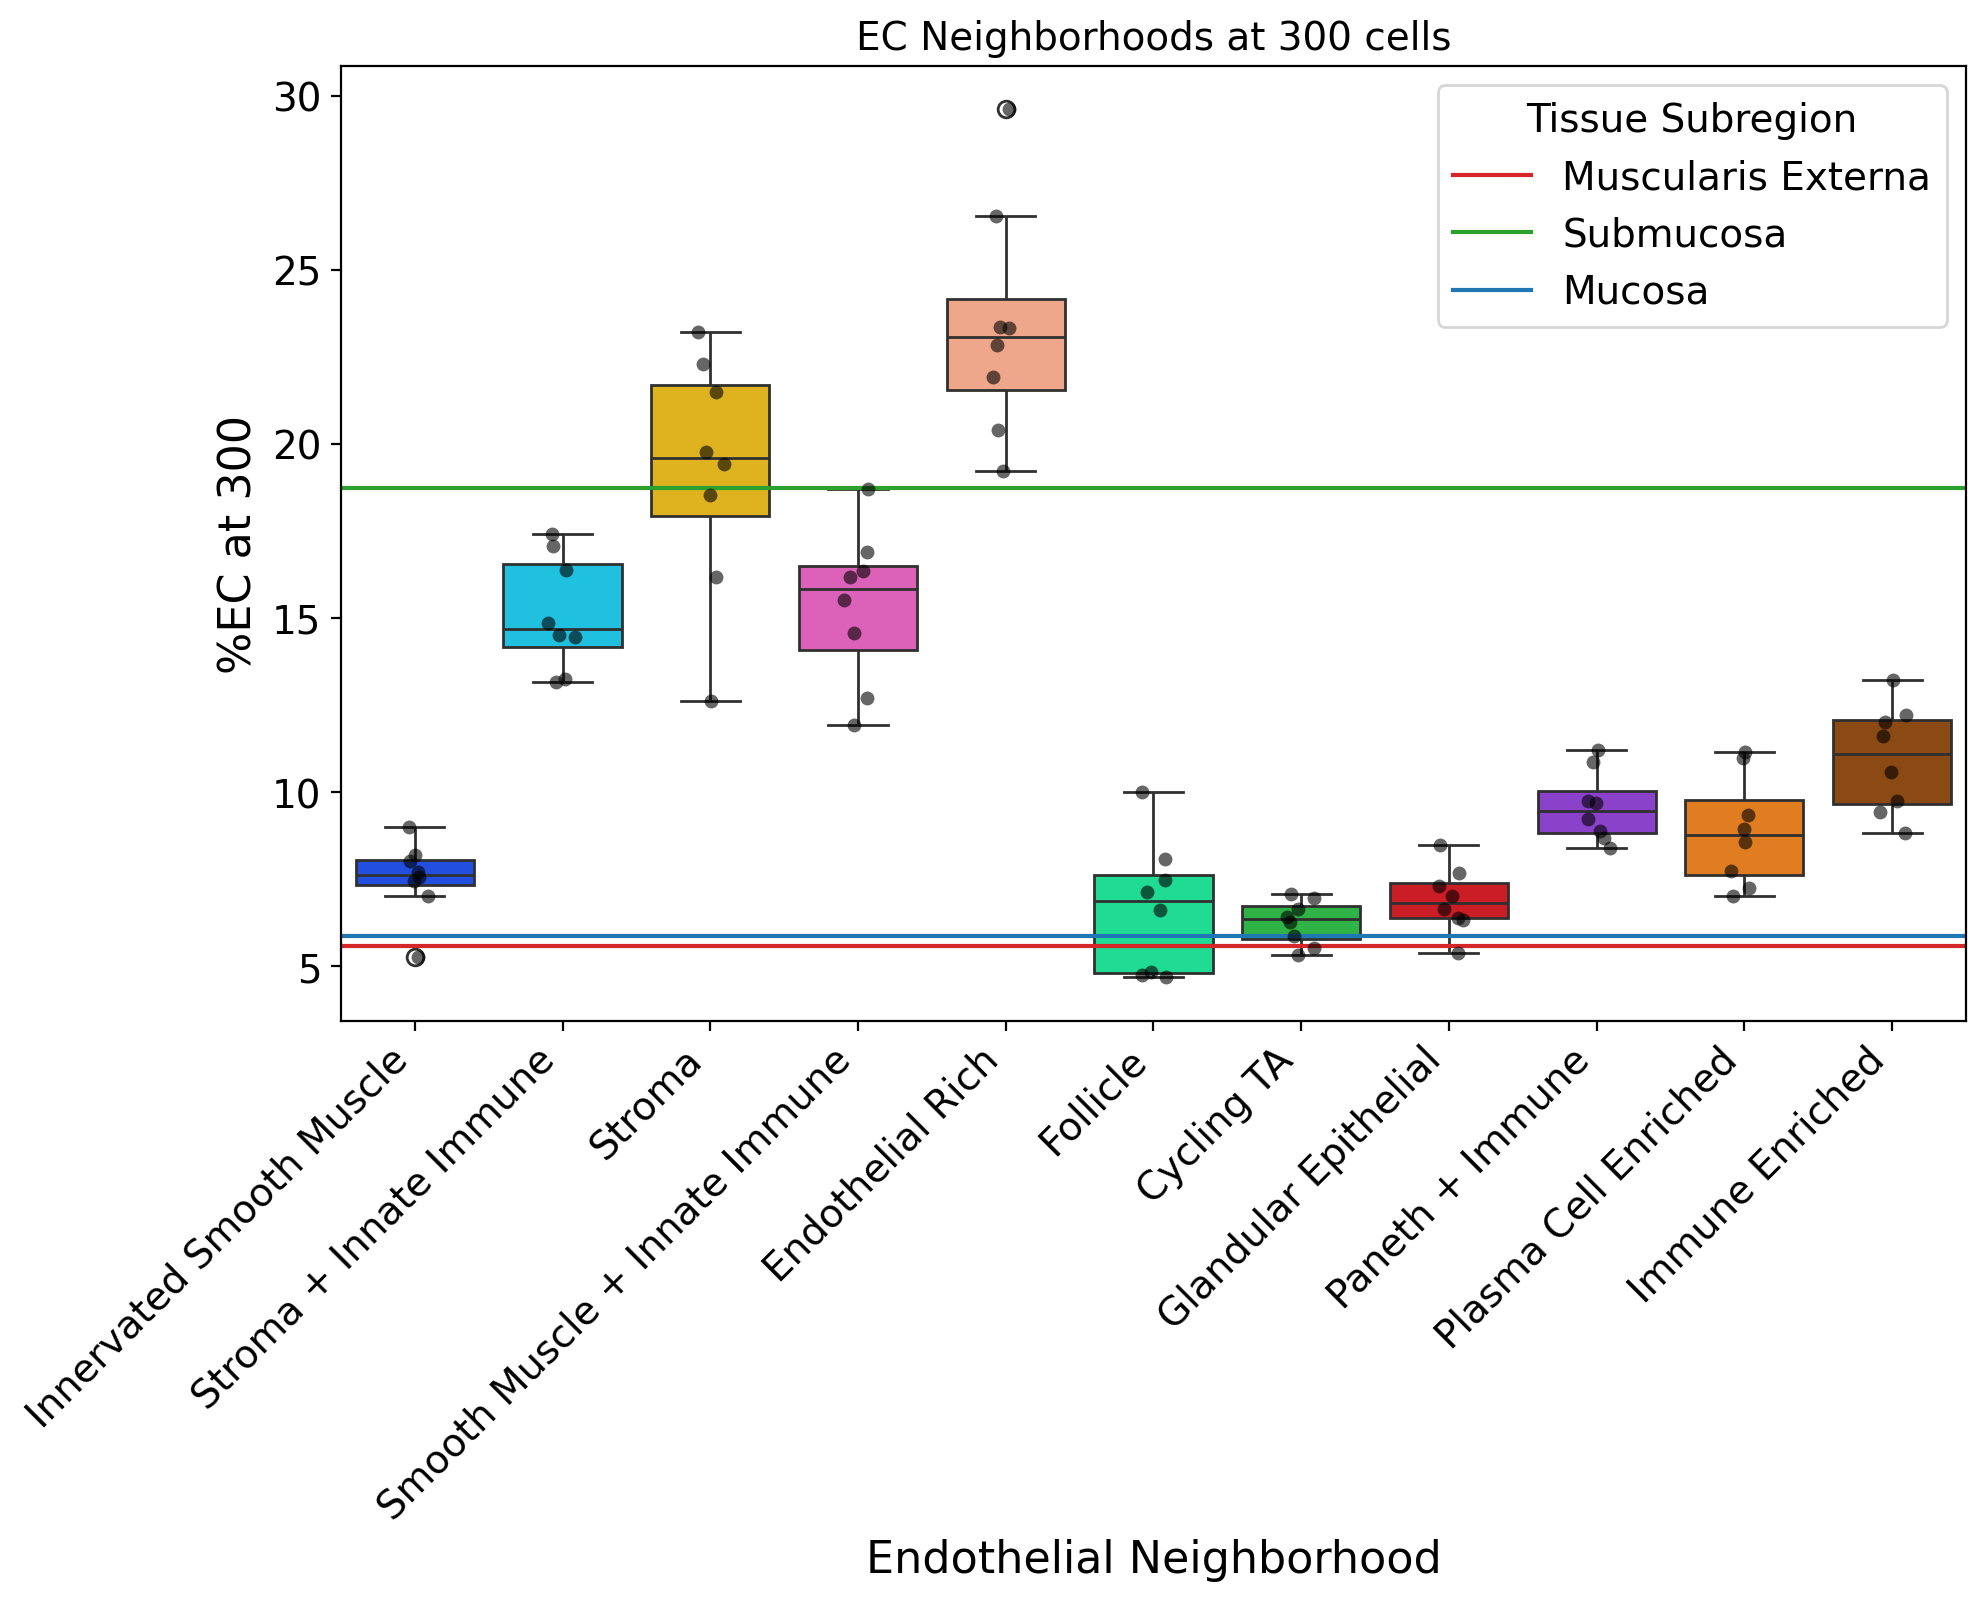

In [56]:
plt.figure(figsize=(10, 6))
sns.boxplot(data=combined_300_df, x='Endothelial Neighborhood', y='Endothelial', palette=custom_palette)
sns.stripplot(data=combined_300_df, x='Endothelial Neighborhood', y='Endothelial', color='black', alpha=0.6, jitter=True )

# plt.axhline(muscularisexterna_average, color='red', linestyle='--', label='Muscularis Externa')
plt.axhline(endo_percent_df.loc[1][1], color=subregion_palette['Muscularis externa'], label='Muscularis Externa')
# plt.axhline(endo_percent_df.loc[2][1], color='yellow', label='Muscularis Mucosa')
# plt.axhline(submucosa_average, color='blue', linestyle='--', label='Submucosa')
plt.axhline(endo_percent_df.loc[3][1], color=subregion_palette['Submucosa'], label='Submucosa')
# plt.axhline(mucosa_average, color='green', linestyle='--', label='Mucosa')
plt.axhline(endo_percent_df.loc[0][1], color=subregion_palette['Mucosa'], label='Mucosa')
plt.ylabel('%EC at 300')
plt.title('EC Neighborhoods at 300 cells')
plt.legend(title = 'Tissue Subregion', loc='upper right')
plt.tight_layout()
plt.xticks(rotation=45, ha='right')
plt.show()

In [57]:
combined_300_df_copy = combined_300_df.copy()
combined_300_df_copy.iloc[[1, 3]] = combined_300_df_copy.iloc[[3, 1]].values
combined_300_df_copy

,Endothelial Neighborhood,Endothelial,Donor,Subregion,Subregion Endothelial %,Normalized Endothelial %
0,Innervated Smooth Muscle,7.028422,B004,Muscularis externa,5.591953,1.256881
1,Smooth Muscle + Innate Immune,14.566749,B004,Muscularis externa,5.591953,2.604948
2,Stroma,18.523835,B004,Submucosa,18.749631,0.987957
3,Stroma + Innate Immune,14.471976,B004,Submucosa,18.749631,0.771854
4,Endothelial Rich,20.402741,B004,Submucosa,18.749631,1.088168
...,...,...,...,...,...,...
83,Cycling TA,6.286032,B008,Mucosa,5.872435,1.070430
84,Glandular Epithelial,6.647928,B008,Mucosa,5.872435,1.132056
85,Paneth + Immune,8.678890,B008,Mucosa,5.872435,1.477903
86,Plasma Cell Enriched,8.586324,B008,Mucosa,5.872435,1.462140


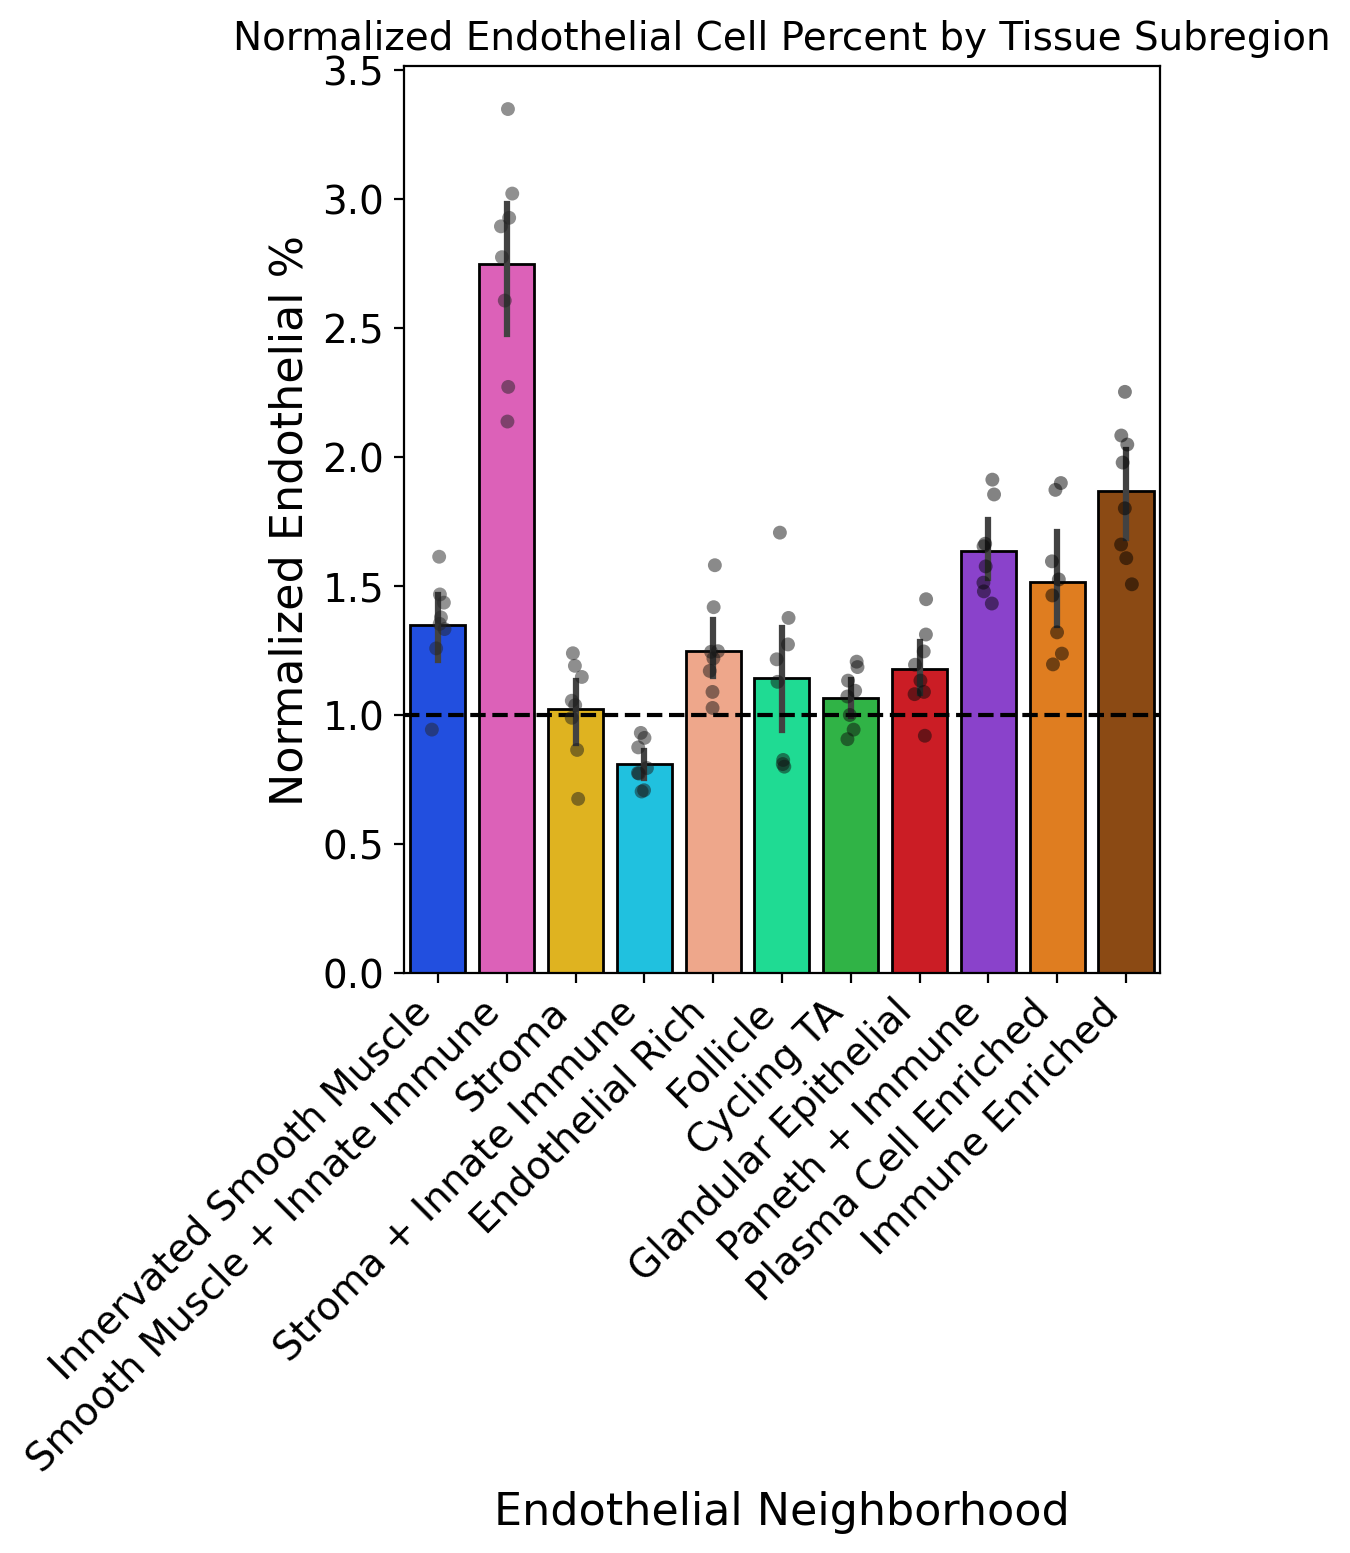

In [58]:
plt.figure(figsize=(6, 8))
ax = sns.barplot(data=combined_300_df_copy, x='Endothelial Neighborhood', y= 'Normalized Endothelial %',
    hue='Endothelial Neighborhood', palette=custom_palette, edgecolor='black' # , orient='h'
    )
sns.stripplot(data=combined_300_df_copy, x='Endothelial Neighborhood', y='Normalized Endothelial %', 
    hue='Endothelial Neighborhood', color='black', ax=ax, jitter=True, alpha=0.5,
)

# plt.ylabel("Endothelial Neighborhood")
plt.title("Normalized Endothelial Cell Percent by Tissue Subregion")
plt.axhline(1.0, color='black', linestyle='--', label='No change (Ratio = 1)')
plt.xticks(rotation=45, ha='right')
# plt.ylim(0,4.0)
plt.tight_layout()
plt.show()

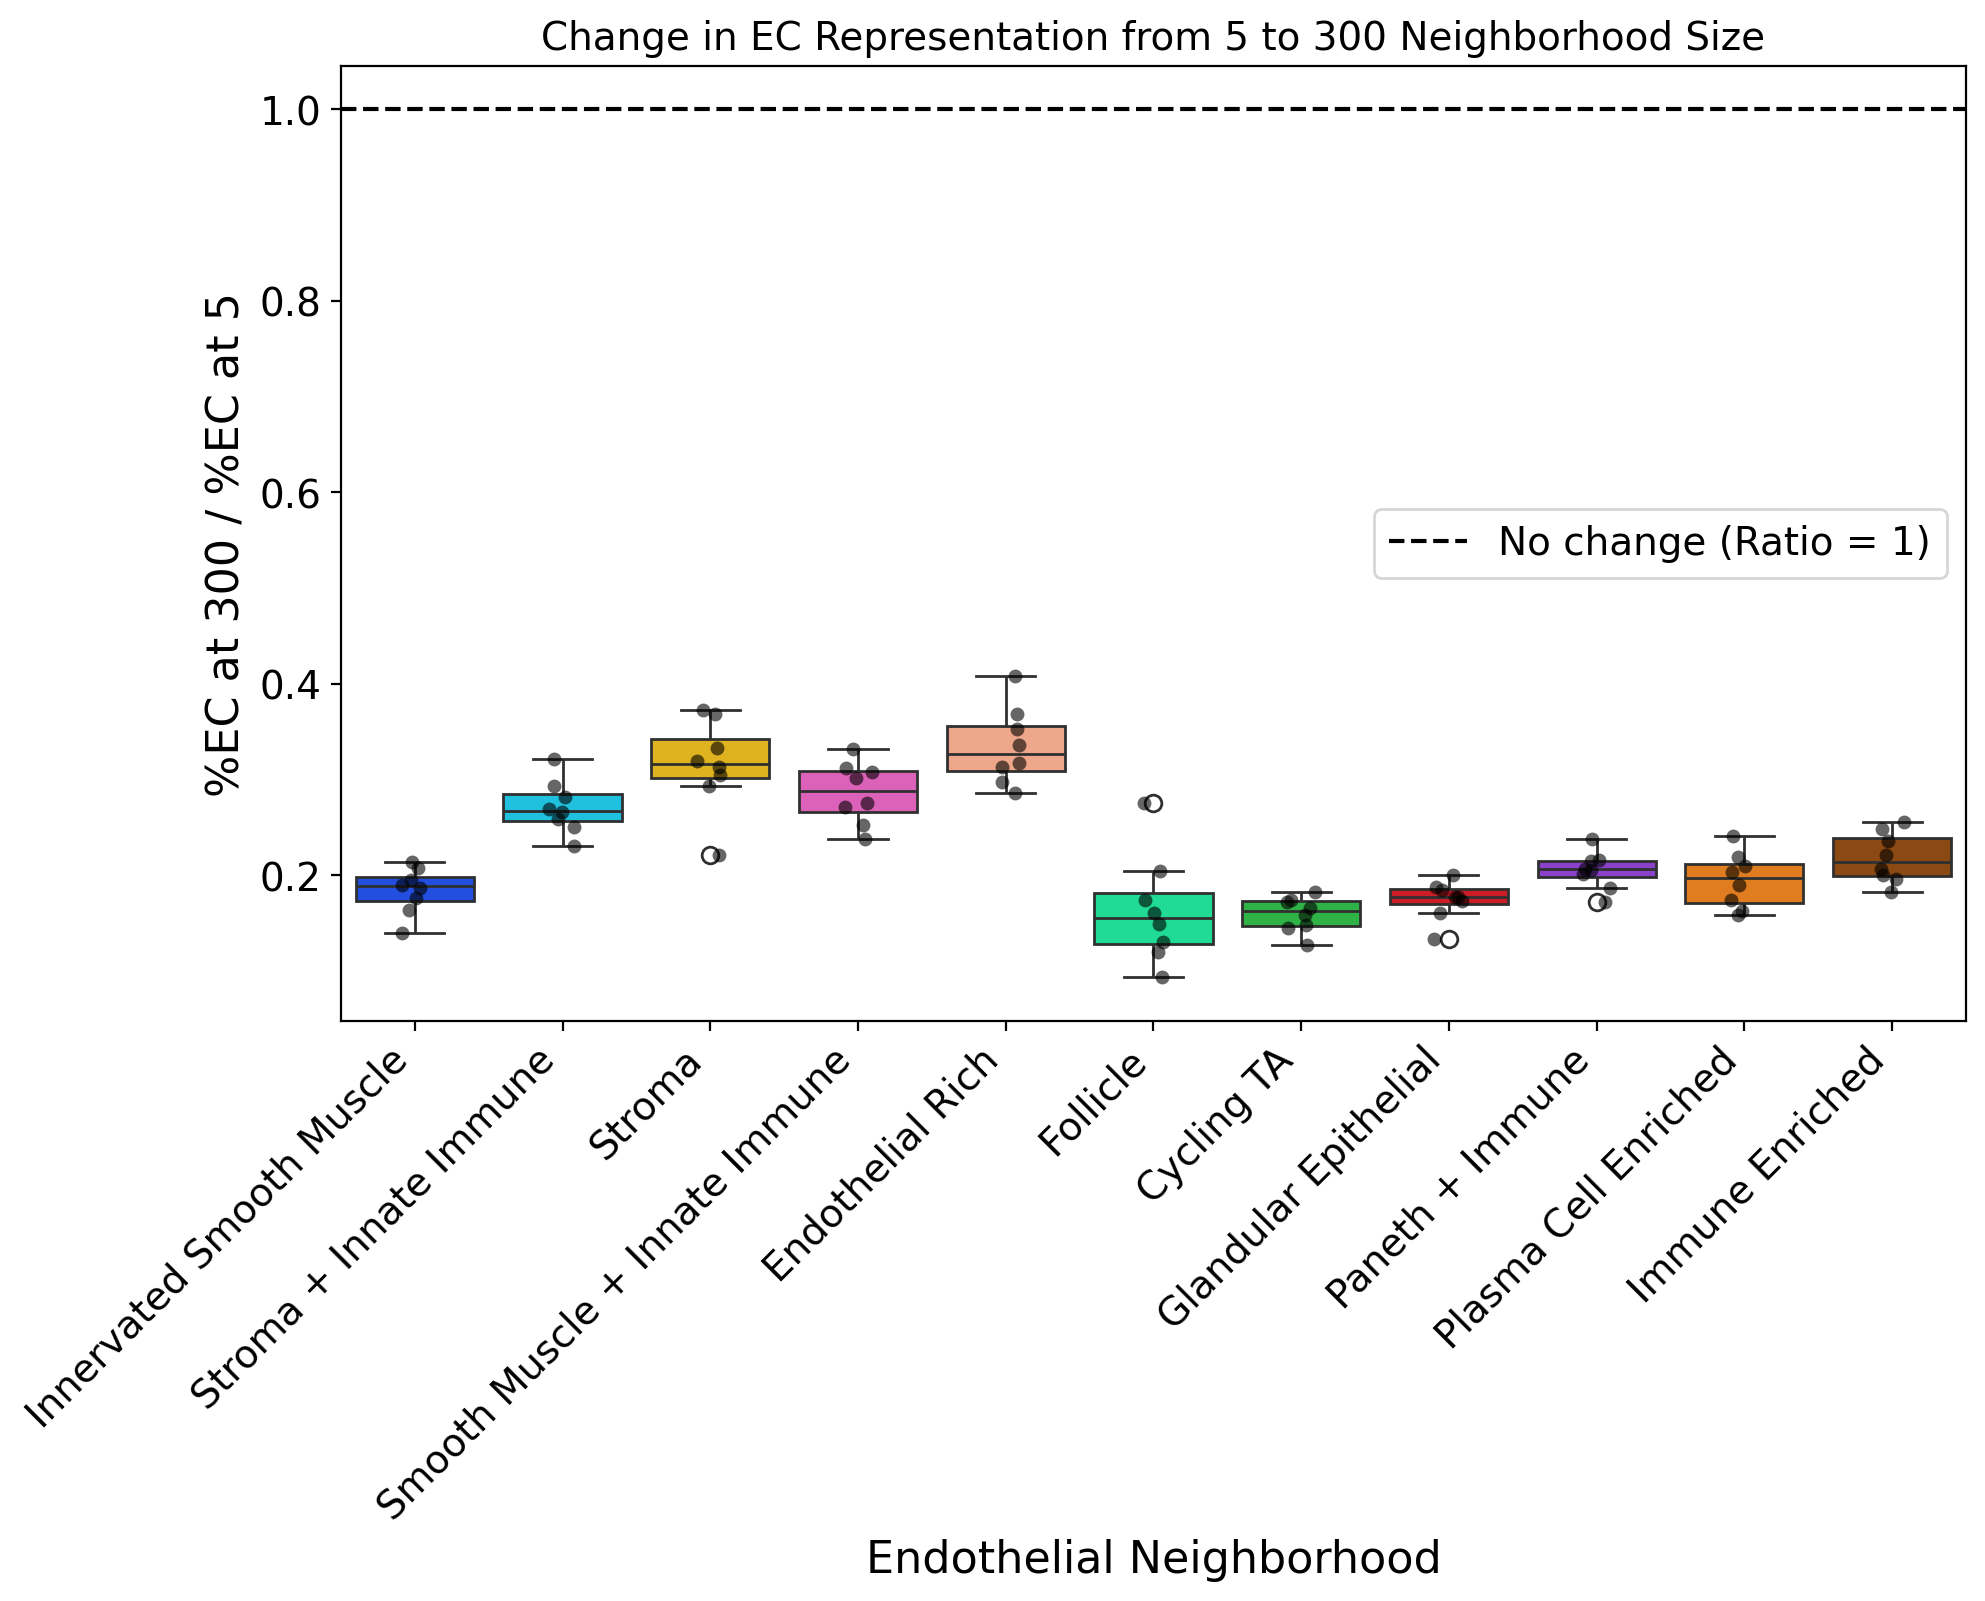

In [59]:
plt.figure(figsize=(10, 6))
sns.boxplot(data=combined_ratio_df, x='Endothelial Neighborhood', y='Endothelial', palette=custom_palette)
sns.stripplot(data=combined_ratio_df, x='Endothelial Neighborhood', y='Endothelial', color='black', alpha=0.6, jitter=True )

plt.axhline(1.0, color='black', linestyle='--', label='No change (Ratio = 1)')
plt.ylabel('%EC at 300 / %EC at 5')
plt.title('Change in EC Representation from 5 to 300 Neighborhood Size')
plt.legend()
plt.tight_layout()
plt.xticks(rotation=45, ha='right')
plt.show()

#### Neighborhood Focused

The material below wasn’t included in the endothelial cell neighborhood analysis.

In [ ]:
#Choose this information and input based on above
ks = [5,10,30,50,100,300] # k=5 means it collects 5 nearest neighbors for each center cell
path_to_data = '/Users/jodie/OneDrive/Documents/Duke/Hickey Lab/23_09_CODEX_HuBMAP_alldata_Dryad_merged.csv'

X = 'x'
Y = 'y'
reg = 'unique_region'
cluster_col = 'Neighborhood'

# cellhier_path = '/content/drive/MyDrive/panorgan/cellhier'
# keep_cols = [X,Y,reg,cluster_col,'Cell Type']
# save_path = '/content/drive/MyDrive/panorgan'

In [ ]:
# ! git clone https://github.com/HickeyLab/Hierarchical-Tissue-Unit-Annotation.git

In [ ]:
#Import Neighborhood Functions and Code
cellhier_path = 'Hierarchical-Tissue-Unit-Annotation/'
sys.path.append(cellhier_path)
from cellhier.general import *
from cellhier.plot_john import *
from cellhier.knn_graph_neighborhood2 import *  # Imports everything

keep_cols = [X,Y,reg,cluster_col,'Cell Type']

In [ ]:
#Import Data
n_neighbors = max(ks)
# sys.path.append(cellhier_path)
# from cellhier.general import *

cells = pd.read_csv(path_to_data)
cells = pd.concat([cells,pd.get_dummies(cells[cluster_col], dtype=int)],axis=1)
sum_cols = cells[cluster_col].unique()
values = cells[sum_cols].values

In [ ]:
#Get each region
tissue_group = cells[[X,Y,reg]].groupby(reg)
exps = list(cells[reg].unique())
tissue_chunks = [(time.time(),exps.index(t),t,a) for t,indices in tissue_group.groups.items() for a in np.array_split(indices,1)]
tissues = [get_windows(job,n_neighbors) for job in tissue_chunks]

In [ ]:
#Loop over k to compute neighborhoods
out_dict = {}
for k in ks:
    for neighbors,job in zip(tissues,tissue_chunks):

        chunk = np.arange(len(neighbors))#indices
        tissue_name = job[2]
        indices = job[3]
        window = values[neighbors[chunk,:k].flatten()].reshape(len(chunk),k,len(sum_cols)).sum(axis = 1)
        out_dict[(tissue_name,k)] = (window.astype(np.float16),indices)

windows = {}
for k in ks:

    window = pd.concat([pd.DataFrame(out_dict[(exp,k)][0],index = out_dict[(exp,k)][1].astype(int),columns = sum_cols) for exp in exps],axis=0)
    window = window.loc[cells.index.values]
    window = pd.concat([cells[keep_cols],window],axis=1)
    windows[k] = window

In [ ]:
os.environ['OMP_NUM_THREADS'] = '4' # For running on Windows with MKL

#Fill in based on above
k = 50
n_neighborhoods = 1
neighborhood_name = "neighborhood"+str(k)
k_centroids = {}

#choose windows with k calculated of interest
windows2 = windows[k]
windows2[cluster_col] = cells[cluster_col]

#Only use T cell windows for example in cell_list
cell_name = 'endothelial cells'
#cell_list = ['Paneth','OLFM4+ Enterocyte']
cell_list = ['Endothelial']
celltype_windows = windows2[windows2['Cell Type'].isin(cell_list)]
type_cells = cells[cells['Cell Type'].isin(cell_list)]

#Add lables
km = MiniBatchKMeans(n_clusters = n_neighborhoods,random_state=0)

labels = km.fit_predict(celltype_windows[sum_cols].values)
k_centroids[k] = km.cluster_centers_
type_cells[neighborhood_name] = labels

#Get out heat
k_to_plot = k
niche_clusters = (k_centroids[k_to_plot])
tissue_avgs = values.mean(axis = 0)
fc = np.log2(((niche_clusters+tissue_avgs)/(niche_clusters+tissue_avgs).sum(axis = 1, keepdims = True))/tissue_avgs)
fc = pd.DataFrame(fc,columns = sum_cols)
fc_output = fc.rename(index={0:k})
fc_output

In [ ]:
def fc_out(data, k_num):
    #Fill in based on above
    k = k_num
    n_neighborhoods = 1
    neighborhood_name = "neighborhood"+str(k)
    k_centroids = {}

    #choose windows with k calculated of interest
    windows2 = windows[k]
    windows2[cluster_col] = data[cluster_col]

    #Only use T cell windows for example in cell_list
    cell_name = 'endothelial data'
    #cell_list = ['Paneth','OLFM4+ Enterocyte']
    cell_list = ['Endothelial']
    celltype_windows = windows2[windows2['Cell Type'].isin(cell_list)]
    type_data = data[data['Cell Type'].isin(cell_list)]

    #Add lables
    km = MiniBatchKMeans(n_clusters = n_neighborhoods,random_state=0)

    labels = km.fit_predict(celltype_windows[sum_cols].values)
    k_centroids[k] = km.cluster_centers_
    type_data[neighborhood_name] = labels

    #Get out heat
    k_to_plot = k
    niche_clusters = (k_centroids[k_to_plot])
    tissue_avgs = values.mean(axis = 0)
    fc = np.log2(((niche_clusters+tissue_avgs)/(niche_clusters+tissue_avgs).sum(axis = 1, keepdims = True))/tissue_avgs)
    fc = pd.DataFrame(fc,columns = sum_cols)
    niche_aveg = pd.DataFrame(niche_clusters,columns = sum_cols)
    niche_avegg = niche_aveg/niche_aveg.sum(axis=1)[0]*100

    fc_output = fc.rename(index={0:k})
    niche_out = niche_avegg.rename(index={0:k})
    return fc_output, niche_out

In [ ]:
fc_list = []
niche_list = []
for kn in ks:
    df1, df2 = fc_out(data=cells, k_num=kn)
    fc_list.append(df1)
    niche_list.append(df2)

fc_comb = pd.concat(fc_list)
niche_comb=pd.concat(niche_list)
niche_comb

In [ ]:
s=sns.clustermap(fc_comb, vmin =-3,vmax = 3,cmap = 'bwr', figsize=(9,6),cbar_pos=(0.01,0.07,0.03,0.1))

s.ax_row_dendrogram.set_visible(False)
s.ax_col_dendrogram.set_visible(False)
#s.ax_heatmap.set_ylabel("", labelpad=25)
#s.ax_heatmap.tick_params(axis='y', pad=15)
#s.ax_heatmap.yaxis.set_ticks_position("left")

#plt.savefig(save_path+'EndothelialCell_enrichment_neigh.png', format='png', dpi=300, transparent=True, bbox_inches='tight')

In [ ]:
s=sns.clustermap(niche_comb, vmax=10, cmap = 'bwr', figsize=(9,6), row_cluster=False)
s.ax_row_dendrogram.set_visible(False)
s.ax_col_dendrogram.set_visible(False)
#plt.savefig(save_path+'Panethcell_percent_neigh.png', format='png', dpi=300, transparent=True, bbox_inches='tight')

In [ ]:
neigh_map = {
 'Transit Amplifying Zone': 'darkblue',
 'Microvasculature': 'black',
 'Adatpive Immune Enriched': 'orange',
 'Glandular Epithelial': 'darkorange',
 'CD66+ Mature Epithelial': 'firebrick',
 'Stroma & Innate Immune': 'brown',
 'CD8+ T Enriched IEL': 'green',
 'Mature Epithelial': 'magenta',
 'Innate Immune Enriched': 'skyblue',
 'Outer Follicle': 'navy',
 'Plasma Cell Enriched': 'yellow',
 'Innervated Stroma': 'blueviolet',
 'Stroma': 'gray',
 'Macrovasculature': 'gold',
 'Secretory Epithelial': 'yellowgreen',
 'Smooth Muscle': 'red',
 'Innervated Smooth Muscle': 'lightgreen',
 'Inner Follicle': 'blue',
 'Smooth Muscle & Innate Immune': 'tan',
 'Paneth Enriched': 'lightblue'}

In [ ]:
#first subplot
ax1 = niche_comb.plot.area(alpha = 0.8, linewidth=1, color=[neigh_map.get(x) for x in niche_comb.columns],figsize =(6.5,4), rot=90)
# ax1 = niche_comb.plot.area(alpha = 0.8, linewidth=1, figsize =(6.5,4), rot=90)
for line in ax1.lines:
    line.set_color('black')
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)
ax1.set_ylabel('percent')

lgd2 = ax1.legend(loc='center left', bbox_to_anchor=(1.0, 0.5), ncol=1, frameon=False)

#plt.savefig(save_path+'Endothelialcell_areaplot_neigh.png', format='png', dpi=300, transparent=True, bbox_inches='tight')

In [ ]:
#Check to make sure that correct values were obtained
celltype_windows[cluster_col].value_counts()

In [ ]:
os.environ['OMP_NUM_THREADS'] = '4' # For running on Windows with MKL
km = MiniBatchKMeans(n_clusters = n_neighborhoods,random_state=0)

labels = km.fit_predict(celltype_windows[sum_cols].values)
k_centroids[k] = km.cluster_centers_
type_cells[neighborhood_name] = labels

In [ ]:
windows2

In [ ]:
#this plot shows the types of cells (ClusterIDs) in the different niches (0-9)
k_to_plot = k
niche_clusters = (k_centroids[k_to_plot])
tissue_avgs = values.mean(axis = 0)
fc = np.log2(((niche_clusters+tissue_avgs)/(niche_clusters+tissue_avgs).sum(axis = 1, keepdims = True))/tissue_avgs)
fc = pd.DataFrame(fc,columns = sum_cols)
s=sns.clustermap(fc_comb, vmin =-3,vmax = 3,cmap = 'bwr',square=True,cbar=True,figsize=(8,5))
#s.savefig(save_path+"celltypes_perniche_"+"_"+str(k)+".png", dpi=600)


#### UMAP visualization - neighborhoods

In [ ]:
import scanpy as sc

##### Format data

In [ ]:
type_cells['neigh_str'] = type_cells['neighborhood'+str(k)].astype(str)
type_cells.columns

In [ ]:
markerlist = [
    'tissue', 'donor', 'region', 'Xcorr', 'Ycorr',
    'Tissue_location', 'array', 'Cell Type', 'Cell Type em','Cell subtype',
    'Neighborhood', 'Neighborhood_Ind', 'Neigh_sub',
    'NeighInd_sub', 'Community', 'Major Community', 'Tissue Segment']

#Add in markers for potential clustering later
markerlist.append('neighborhood'+str(k))

marker_df = type_cells[markerlist]


#turn into dictionary so I can extract values later for dataframe
tfc = fc.T
#key 1 is neighborhood number, #key 2 is the cell type
dict_tfc = tfc.to_dict()
#Map back with neighborhood number
for cell_type_unique in dict_tfc[0].keys():
    marker_df[str('Enriched ')+cell_type_unique] = marker_df['neighborhood'+str(k)].apply(lambda x:dict_tfc[x][cell_type_unique])

marker_df['Community'].unique()

In [ ]:
comb_df = pd.concat([celltype_windows, marker_df], axis=1)
comb_df

In [ ]:
#Read in Data and Rename ClusterID with Named Values
df = comb_df.copy()
#make neighborhood not an integer
df['neighborhood'+str(k)] = df['neighborhood'+str(k)].astype(str)
df['neighborhood'+str(k)]

In [ ]:
cell_enr = [
    'Enriched Mature Epithelial', 'Enriched Transit Amplifying Zone',
       'Enriched Innate Immune Enriched', 'Enriched Stroma & Innate Immune',
       'Enriched Outer Follicle', 'Enriched Adatpive Immune Enriched',
       'Enriched Secretory Epithelial', 'Enriched CD66+ Mature Epithelial',
       'Enriched Plasma Cell Enriched', 'Enriched Innervated Stroma',
       'Enriched Smooth Muscle & Innate Immune', 'Enriched Microvasculature',
       'Enriched Innervated Smooth Muscle', 'Enriched Inner Follicle',
       'Enriched Macrovasculature', 'Enriched Stroma',
       'Enriched Glandular Epithelial', 'Enriched CD8+ T Enriched IEL',
       'Enriched Smooth Muscle', 'Enriched Paneth Enriched'
]
collist = [
       'x', 'y', 'unique_region', 'tissue',
       'donor', 'region', 'Xcorr', 'Ycorr', 'Tissue_location', 'array', 'Cell Type',
       'Cell subtype', 'Neighborhood', 'Neighborhood_Ind',
       'Neigh_sub', 'NeighInd_sub', 'Community', 'Major Community','Tissue Segment'
 ]
#Prepare for making into anndata format so that obs and data are separate
windows_list = [
       'Mature Epithelial', 'Transit Amplifying Zone',
       'Innate Immune Enriched', 'Stroma & Innate Immune', 'Outer Follicle',
       'Adatpive Immune Enriched', 'Secretory Epithelial',
       'CD66+ Mature Epithelial', 'Plasma Cell Enriched', 'Innervated Stroma',
       'Smooth Muscle & Innate Immune', 'Microvasculature',
       'Innervated Smooth Muscle', 'Inner Follicle', 'Macrovasculature',
       'Stroma', 'Glandular Epithelial', 'CD8+ T Enriched IEL',
       'Smooth Muscle', 'Paneth Enriched',]

In [ ]:
df1 = df.drop(columns = collist) #USER INPUT
df1.columns

In [ ]:
#Prepare for making into anndata format
dfw = df[windows_list]
dfw.columns

In [ ]:
#Convert to anndata format
adata_w = sc.AnnData(dfw)
collist.extend(cell_enr)

adata_w.obs = df[collist]
adata_w


##### Leiden clustering in replacement of K means

In [ ]:
sc.settings.figdir='single_cell_neighborhood'
sc.settings.set_figure_params(dpi=80, facecolor='white',dpi_save=300, transparent=True, frameon=False, fontsize=22)
plt.rcParams["legend.markerscale"] = 1



In [ ]:
print(adata_w.obs['Community'].unique())
print(adata_w.obs.columns)
print(adata_w.obs)

In [ ]:
sc.pp.neighbors(adata_w, n_neighbors=20)
sc.tl.umap(adata_w)
sc.pl.umap(adata_w, color ='Community',)

In [ ]:
sc.pl.umap(adata_w, color ='Tissue_location',)